In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/favorita-grocery-sales-forecasting/test.csv.7z
/kaggle/input/competitions/favorita-grocery-sales-forecasting/stores.csv.7z
/kaggle/input/competitions/favorita-grocery-sales-forecasting/items.csv.7z
/kaggle/input/competitions/favorita-grocery-sales-forecasting/holidays_events.csv.7z
/kaggle/input/competitions/favorita-grocery-sales-forecasting/transactions.csv.7z
/kaggle/input/competitions/favorita-grocery-sales-forecasting/train.csv.7z
/kaggle/input/competitions/favorita-grocery-sales-forecasting/oil.csv.7z
/kaggle/input/competitions/favorita-grocery-sales-forecasting/sample_submission.csv.7z


In [2]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.3/495.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 11.6 MB/s eta 0:00:00


In [3]:
import py7zr
import os

input_path = "/kaggle/input/competitions/favorita-grocery-sales-forecasting/"
extract_path = "/kaggle/working/data/"

os.makedirs(extract_path, exist_ok=True)

files = [
    "train.csv.7z",
    "test.csv.7z",
    "stores.csv.7z",
    "items.csv.7z",
    "oil.csv.7z",
    "transactions.csv.7z",
    "holidays_events.csv.7z",
    "sample_submission.csv.7z"
]

for f in files:
    with py7zr.SevenZipFile(input_path + f, mode='r') as z:
        z.extractall(path=extract_path)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

data_path = "/kaggle/working/data/"

train = pd.read_csv(data_path + "train.csv", parse_dates=['date'])
test = pd.read_csv(data_path + "test.csv", parse_dates=['date'])
stores = pd.read_csv(data_path + "stores.csv")
items = pd.read_csv(data_path + "items.csv")
oil = pd.read_csv(data_path + "oil.csv", parse_dates=['date'])
transactions = pd.read_csv(data_path + "transactions.csv", parse_dates=['date'])
holidays = pd.read_csv(data_path + "holidays_events.csv", parse_dates=['date'])

/tmp/ipykernel_57/1983315140.py:10: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(data_path + "train.csv", parse_dates=['date'])


In [5]:
def reduce_mem_usage(df):
    for col in df.columns:
        if df[col].dtype != 'object':
            df[col] = pd.to_numeric(df[col], downcast='float')
    return df

train = reduce_mem_usage(train)

# Sampling for EDA
sample_df = train.sample(2_000_000, random_state=42)

sample_df['date'] = pd.to_datetime(sample_df['date'])

# **Data cleaning**

In [6]:
sample_df['onpromotion'] = sample_df['onpromotion'].fillna(False)
sample_df['unit_sales'] = sample_df['unit_sales'].clip(lower=0)
sample_df['log_sales'] = np.log1p(sample_df['unit_sales'])

# FEATURE TIME
sample_df['dow'] = sample_df['date'].dt.dayofweek
sample_df['month'] = sample_df['date'].dt.month
sample_df['year'] = sample_df['date'].dt.year

/tmp/ipykernel_57/3915019644.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sample_df['onpromotion'] = sample_df['onpromotion'].fillna(False)


# **Basic Overview**

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125497040 entries, 0 to 125497039
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           float64
 1   date         float64
 2   store_nbr    float32
 3   item_nbr     float32
 4   unit_sales   float32
 5   onpromotion  object 
dtypes: float32(3), float64(2), object(1)
memory usage: 4.2+ GB


In [8]:
train.describe()

,id,date,store_nbr,item_nbr,unit_sales
count,1.254970e+08,1.254970e+08,1.254970e+08,1.254970e+08,1.254970e+08
mean,6.274852e+07,1.442335e+18,2.746453e+01,9.727683e+05,8.554856e+00
std,3.622788e+07,4.014999e+16,1.735906e+01,7.667841e+05,2.306714e+01
min,0.000000e+00,1.356998e+18,1.000000e+00,9.699500e+04,-1.537200e+04
25%,3.137426e+07,1.411171e+18,1.200000e+01,5.223830e+05,2.000000e+00
50%,6.274852e+07,1.448064e+18,2.800000e+01,9.595000e+05,4.000000e+00
75%,9.412278e+07,1.476662e+18,4.300000e+01,1.354380e+06,9.000000e+00
max,1.254970e+08,1.502755e+18,5.400000e+01,2.127114e+06,8.944000e+04


In [9]:
train.isnull().sum()

id                    0
date                  0
store_nbr             0
item_nbr              0
unit_sales            0
onpromotion    21657651
dtype: int64

# **Train**

## **Target Distribution**

Text(0.5, 1.0, 'Log Sales Distribution')

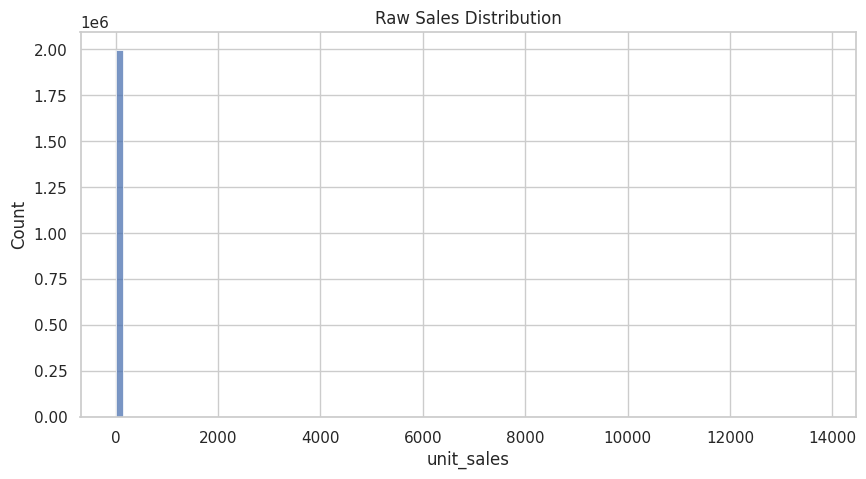

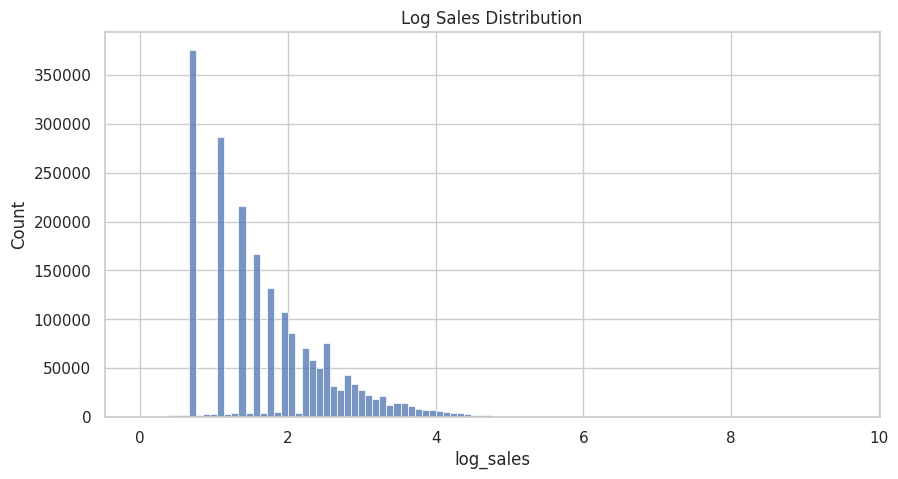

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(sample_df['unit_sales'], bins=100)
plt.title("Raw Sales Distribution")

plt.figure(figsize=(10,5))
sns.histplot(sample_df['log_sales'], bins=100)
plt.title("Log Sales Distribution")

## **Sales Over Time**

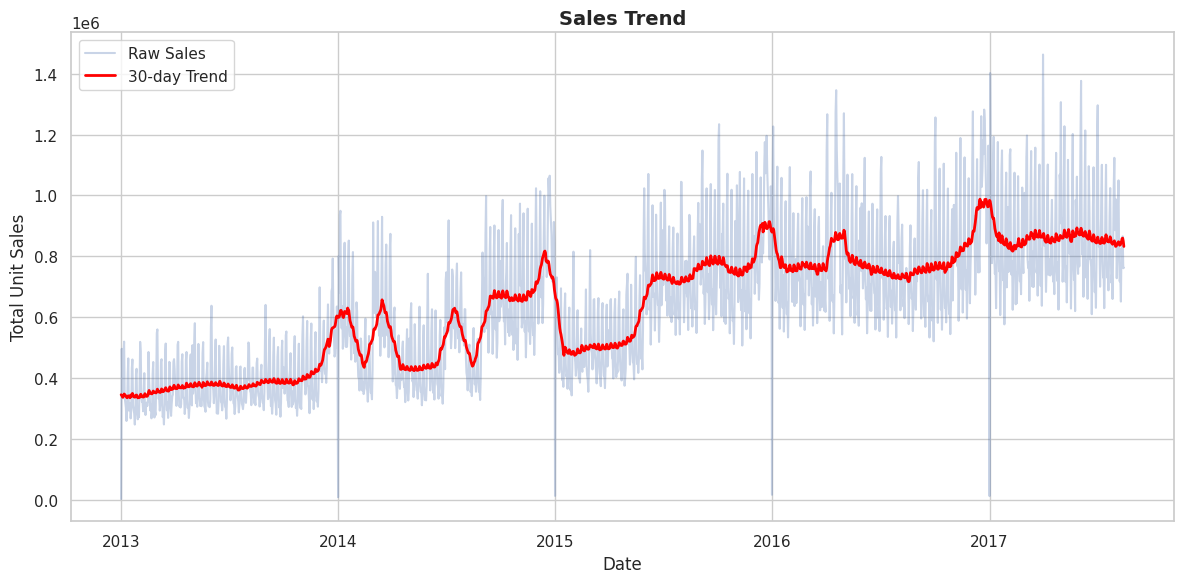

In [11]:
sales = train.groupby('date')['unit_sales'].sum().reset_index()

sales['date'] = pd.to_datetime(sales['date'])

plt.figure(figsize=(12,6))

plt.plot(sales['date'], sales['unit_sales'], alpha=0.3, label='Raw Sales')

sales['rolling_30'] = sales['unit_sales'].rolling(30, center=True, min_periods=1).mean()
plt.plot(sales['date'], sales['rolling_30'], color='red', linewidth=2, label='30-day Trend')

plt.legend()
plt.title("Sales Trend", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Total Unit Sales")
plt.tight_layout()
plt.show()

Biểu đồ cho thấy tổng doanh số có xu hướng tăng dần theo thời gian từ năm 2013 đến 2017. Đường 30-day rolling mean (màu đỏ) giúp làm mượt dữ liệu và cho thấy rõ xu hướng tăng trưởng dài hạn của doanh số. Ngoài ra, dữ liệu xuất hiện nhiều đợt biến động mạnh và các spike doanh số lớn, đặc biệt trong giai đoạn từ 2015 trở đi. Biên độ dao động của doanh số cũng ngày càng lớn theo thời gian, cho thấy mức độ biến động của thị trường tăng lên đáng kể.

Điều này phản ánh rằng hệ thống bán lẻ đang phát triển theo thời gian với nhu cầu tiêu dùng ngày càng tăng. Tuy nhiên, doanh số không tăng một cách ổn định mà chịu ảnh hưởng mạnh bởi nhiều yếu tố như:
- Seasonal events (lễ, tết, cuối năm)
- Promotion 
- Thói quen mua sắm theo thời điểm
- Các yếu tố kinh tế bên ngoài

Các đỉnh tăng trưởng lớn có thể đại diện cho các giai đoạn cao điểm tiêu dùng hoặc các chiến dịch khuyến mãi quy mô lớn. Đặc biệt, từ năm 2015 trở đi, rolling trend tăng nhanh hơn cho thấy doanh nghiệp có thể đã mở rộng hệ thống cửa hàng hoặc tăng trưởng mạnh về lượng khách hàng.

Biểu đồ cho thấy dữ liệu mang đặc trưng rõ rệt của bài toán time-series forecasting:
- Có trend dài hạn (long-term trend)
- Có seasonality
- Có volatility cao
- Có temporal dependency

Điều này cho thấy việc chỉ sử dụng dữ liệu gốc sẽ không đủ để mô hình học tốt. **Cần tạo thêm các temporal features như:** day_of_week, month, year, lag features, rolling mean, rolling std

Ngoài ra, do variance tăng theo thời gian, các mô hình boosting như: XGBoost, LightGBM, CatBoost sẽ phù hợp hơn linear models truyền thống. Insight này cũng cho thấy việc sử dụng random split là không phù hợp vì có thể gây data leakage trong bài toán forecasting.

**Từ góc nhìn kinh doanh** xu hướng doanh số tăng dần theo thời gian cùng với mức độ biến động ngày càng lớn cho thấy nhu cầu tiêu dùng của khách hàng không ổn định mà thay đổi mạnh theo từng giai đoạn. Điều này giúp doanh nghiệp có thể chủ động dự đoán các thời điểm cao điểm mua sắm để chuẩn bị hàng tồn kho, tối ưu logistics và phân bổ nhân sự phù hợp theo mùa. Đồng thời, doanh nghiệp cũng có thể xây dựng các chiến lược promotion hiệu quả hơn trong những giai đoạn doanh số thấp nhằm kích thích nhu cầu tiêu dùng. Bên cạnh đó, mức volatility tăng mạnh theo thời gian cho thấy tầm quan trọng của một hệ thống forecasting chính xác để hạn chế tình trạng thiếu hàng trong mùa cao điểm, giảm tồn kho dư thừa và tối ưu doanh thu tổng thể.

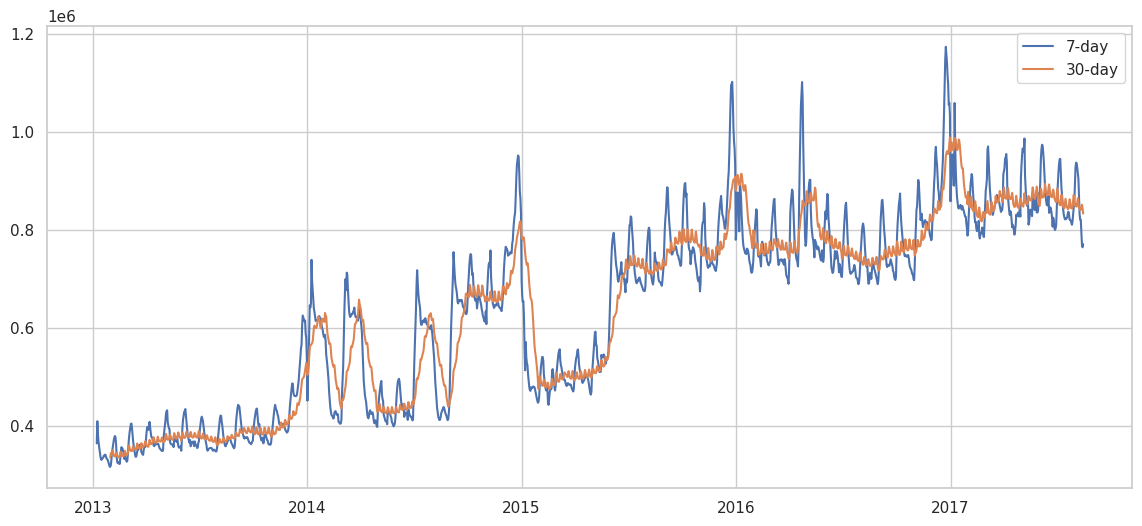

In [12]:
sales['rolling_7'] = sales['unit_sales'].rolling(7).mean()
sales['rolling_30'] = sales['unit_sales'].rolling(30).mean()

plt.figure(figsize=(14,6))
plt.plot(sales['date'], sales['rolling_7'], label='7-day')
plt.plot(sales['date'], sales['rolling_30'], label='30-day')
plt.legend()

## **Seasonality Analysis**

Text(0.5, 32.249999999999986, 'Month')

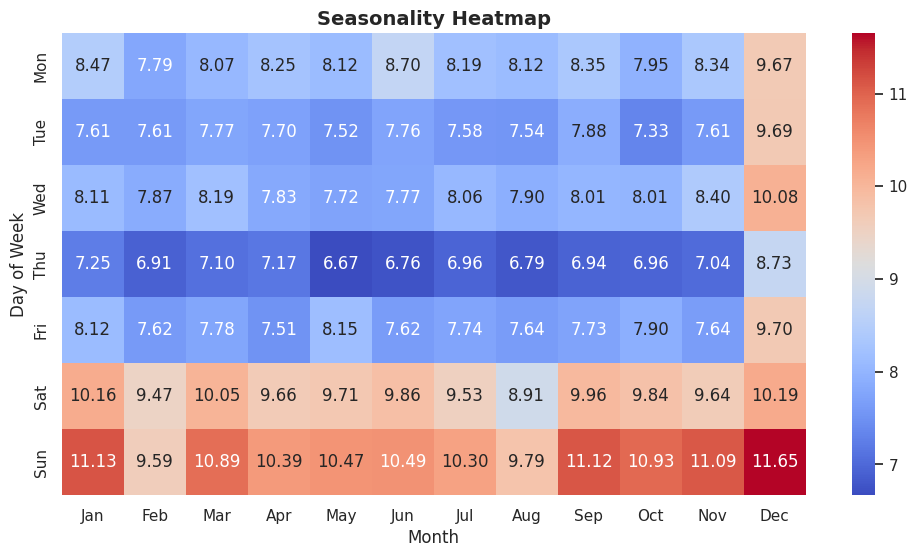

In [13]:
pivot = sample_df.pivot_table(
    index='dow',
    columns='month',
    values='unit_sales',
    aggfunc='mean'
)

pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Seasonality Heatmap", fontsize=14, fontweight='bold')
plt.ylabel("Day of Week")
plt.xlabel("Month")

Biểu đồ heatmap cho thấy doanh số có tính seasonality rất rõ rệt theo cả ngày trong tuần và các tháng trong năm. Chủ nhật là ngày có doanh số cao nhất gần như xuyên suốt toàn bộ năm, với giá trị dao động từ khoảng 9.59 đến 11.65, trong đó tháng 12 đạt mức cao nhất toàn bộ heatmap với 11.65. Ngược lại, các ngày giữa tuần như Thứ Năm thường có doanh số thấp hơn đáng kể, chỉ dao động quanh mức 6.67 - 8.73. Điều này cho thấy nhu cầu mua sắm của khách hàng tăng mạnh vào cuối tuần, đặc biệt là Chủ nhật khi người tiêu dùng có nhiều thời gian hơn cho hoạt động mua sắm và tiêu dùng.

Ngoài ra, **tháng 12 nổi bật** với mức doanh số tăng mạnh ở hầu hết các ngày trong tuần, ví dụ:
- Monday tăng lên 9.67
- Wednesday đạt 10.08
- Friday đạt 9.70
- Saturday đạt 10.19
- Sunday đạt đỉnh 11.65

So với các tháng thông thường chỉ dao động quanh mức 7 đến 9, đây là mức tăng rất đáng kể, phản ánh ảnh hưởng mạnh của mùa lễ hội, cuối năm và các chiến dịch promotion lớn. Insight này cho thấy dữ liệu tồn tại đồng thời:
- weekly seasonality (chu kỳ theo tuần)
- annual seasonality (chu kỳ theo năm)

Đối với forecasting model, đây là tín hiệu rất quan trọng vì nếu mô hình không học được các seasonal patterns này thì sai số dự báo ở các giai đoạn cao điểm sẽ tăng mạnh. **Do đó cần xây dựng các feature như: day_of_week, is_weekend, month, holiday season, cyclical encoding để giúp mô hình học tốt hơn hành vi tiêu dùng theo thời gian.**

**Từ góc nhìn kinh doanh** heatmap cho thấy doanh nghiệp cần đặc biệt chú trọng vào các giai đoạn cuối tuần và cuối năm – thời điểm nhu cầu mua sắm tăng mạnh nhất. Điều này giúp doanh nghiệp chủ động chuẩn bị hàng tồn kho, tối ưu chuỗi cung ứng và tăng cường nhân sự tại các thời điểm cao điểm nhằm tránh tình trạng thiếu hàng hoặc quá tải vận hành. Đồng thời, insight này cũng hỗ trợ xây dựng các chiến lược marketing và promotion theo mùa hiệu quả hơn, đặc biệt trong tháng 12 khi sức mua của khách hàng đạt mức cao nhất trong năm.

## **Promotion Analysis**

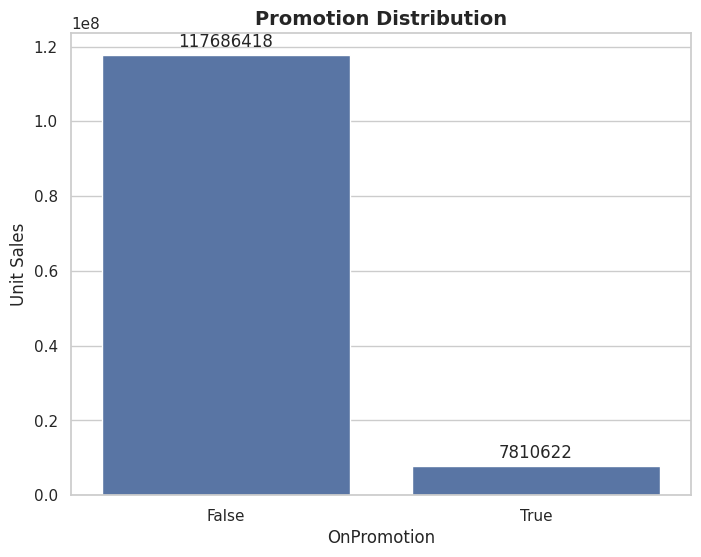

In [50]:
plt.figure(figsize=(8, 6))
ax1 = sns.countplot(x='onpromotion', data=train)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.0f', padding=3)
plt.title("Promotion Distribution", fontsize=14, fontweight='bold')
plt.xlabel("OnPromotion")
plt.ylabel("Unit Sales")
plt.show()

Biểu đồ cho thấy phần lớn doanh số đến từ các sản phẩm không có khuyến mãi (OnPromotion = False). Cụ thể, tổng unit_sales của nhóm không promotion đạt khoảng 117,686,418 trong khi nhóm có promotion chỉ đạt khoảng 7,810,622. Điều này cho thấy doanh số từ các sản phẩm không được khuyến mãi cao gấp hơn 15 lần so với nhóm có promotion.

Tuy nhiên, điều này không đồng nghĩa promotion không hiệu quả. Trên thực tế, số lượng sản phẩm hoặc số ngày không promotion trong dữ liệu lớn hơn rất nhiều so với các trường hợp có promotion, nên tổng doanh số tự nhiên sẽ cao hơn. Điều quan trọng là promotion vẫn tạo ra các demand spikes đáng kể trong những thời điểm cụ thể và đóng vai trò kích thích hành vi mua sắm của khách hàng.

Biểu đồ phản ánh rằng hoạt động promotion chỉ được áp dụng cho một phần nhỏ sản phẩm hoặc trong các giai đoạn nhất định, thay vì triển khai đại trà trên toàn hệ thống. Điều này cho thấy doanh nghiệp đang sử dụng promotion như một chiến lược tối ưu doanh thu có chọn lọc nhằm:
- tăng nhu cầu ngắn hạn
- kích cầu cho một số nhóm sản phẩm
- thúc đẩy doanh số trong các giai đoạn thấp điểm

Đối với forecasting model, onpromotion là feature rất quan trọng vì dù số lượng promotion không lớn, nhưng chúng có thể tạo ra biến động doanh số mạnh trong ngắn hạn. Nếu mô hình bỏ qua feature này, khả năng dự báo các spike doanh số sẽ giảm đáng kể, đặc biệt trong các mùa campaign hoặc dịp lễ. Do đó, cần xây dựng thêm các promotion-related features như: số ngày promotion liên tiếp, promotion intensity, rolling promotion count, interaction giữa promotion và holiday.

**Từ góc nhìn kinh doanh** giúp doanh nghiệp hiểu rằng promotion không cần xuất hiện thường xuyên để tạo tác động lớn lên hành vi tiêu dùng. Việc triển khai promotion đúng thời điểm và đúng nhóm sản phẩm có thể giúp tối ưu doanh thu, tăng lượng khách hàng và cải thiện hiệu quả bán hàng mà không cần giảm giá trên diện rộng.

In [ ]:
plt.figure(figsize=(8, 6))
ax2 = sns.boxplot(x='onpromotion', y='unit_sales', data=train)
plt.title("Promotion Impact", fontsize=14, fontweight='bold')
plt.xlabel("OnPromotion")
plt.ylabel("Unit Sales")
plt.show()

In [ ]:
sample_item = train['item_nbr'].sample(1).iloc[0]
sub = sample_df[sample_df['item_nbr'] == sample_item]

plt.figure(figsize=(12,6))
sns.scatterplot(x='date', y='unit_sales', hue='onpromotion', data=sub)
plt.title(f"Sales Trend for Item {sample_item}", fontsize=14, fontweight='bold')
plt.show()

onpromotion           False      True 
family                                
BEVERAGES         11.907194  21.929115
BREAD/BAKERY       8.990979  10.063407
CLEANING           5.568709   9.385999
DAIRY              7.188142   7.339814
DELI               5.797948   6.110070
EGGS               9.648759  11.816973
FROZEN FOODS       8.482524  14.217251
GROCERY I          7.336217  12.505603
HOME CARE          5.407988   8.029582
LIQUOR,WINE,BEER   7.448291   9.311688
MEATS             11.963578  15.759584
PERSONAL CARE      5.347713   7.318896
POULTRY           18.131020  19.917999
PREPARED FOODS    11.108002  10.860921
PRODUCE           16.306505  21.813171


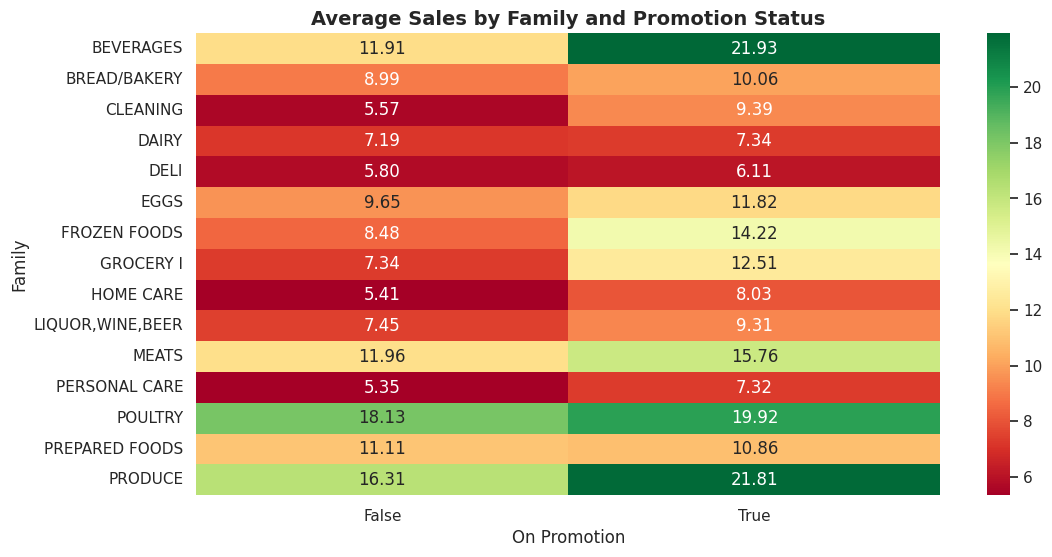

In [38]:
promo_df = sample_df.merge(items[['item_nbr', 'family']], on='item_nbr', how='left')

family_promo = promo_df.groupby(['family', 'onpromotion'], as_index=False)['unit_sales'].mean()

top_family = promo_df.groupby('family', as_index=False)['unit_sales'].sum() \
                     .sort_values('unit_sales', ascending=False) \
                     .head(15)

family_promo_top = family_promo[family_promo['family'].isin(top_family['family'])]

family_promo_pivot = family_promo_top.pivot(index='family', columns='onpromotion', values='unit_sales')

print(family_promo_pivot)

plt.figure(figsize=(12,6))
sns.heatmap(family_promo_pivot, cmap='RdYlGn', annot=True, fmt='.2f')
plt.title('Average Sales by Family and Promotion Status', fontsize=14, fontweight='bold')
plt.xlabel('On Promotion')
plt.ylabel('Family')
plt.show()

**Promotion không xuất hiện thường xuyên, nhưng mỗi lần xuất hiện lại có khả năng làm tăng doanh số trung bình khá mạnh ở nhiều nhóm sản phẩm.**

Biểu đồ heatmap cho thấy promotion có tác động khác nhau lên từng nhóm sản phẩm (family), tuy nhiên phần lớn các nhóm đều ghi nhận mức doanh số trung bình cao hơn khi được khuyến mãi (On Promotion = True). Một số nhóm sản phẩm có mức tăng trưởng rất mạnh khi áp dụng promotion, nổi bật như:
- BEVERAGES tăng từ 11.91 lên 21.93 (~84%)
- PRODUCE tăng từ 16.31 lên 21.81
- FROZEN FOODS tăng từ 8.48 lên 14.22
- GROCERY I tăng từ 7.34 lên 12.51
- CLEANING tăng mạnh từ 5.57 lên 9.39

Điều này cho thấy các nhóm sản phẩm tiêu dùng nhanh và thiết yếu phản ứng rất mạnh với các chương trình promotion. Người tiêu dùng có xu hướng mua tích trữ nhiều hơn khi các mặt hàng thực phẩm, đồ uống hoặc hàng tiêu dùng được giảm giá.

Ngược lại, một số nhóm có mức thay đổi nhỏ hoặc gần như không tăng đáng kể, ví dụ:
- DAIRY chỉ tăng nhẹ từ 7.19 lên 7.34
- DELI tăng từ 5.80 lên 6.11
- PREPARED FOODS gần như không đổi, thậm chí giảm nhẹ từ 11.11 xuống 10.86

Có thể thấy không phải tất cả các nhóm sản phẩm đều hưởng lợi giống nhau từ promotion. Một số nhóm có nhu cầu ổn định tự nhiên nên promotion không tạo khác biệt lớn, trong khi các nhóm tiêu dùng nhanh có độ nhạy giá cao hơn nhiều.

Đối với forecasting model, đây là insight rất quan trọng vì nó cho thấy tồn tại sự tương tác mạnh giữa family và onpromotion. Do đó, nếu chỉ sử dụng feature promotion đơn lẻ mà không kết hợp với family, mô hình có thể bỏ lỡ nhiều tín hiệu quan trọng. Vì vậy nên **tạo thêm các interaction features như: family x promotion, promotion intensity theo family, rolling promotion effect theo family** để giúp mô hình học chính xác hơn hành vi tiêu dùng của từng nhóm sản phẩm.

**Từ góc nhìn kinh doanh** giúp doanh nghiệp xác định nhóm sản phẩm nào phản ứng mạnh nhất với promotion để tối ưu ngân sách marketing và chiến lược giảm giá. Thay vì triển khai promotion đại trà, doanh nghiệp có thể tập trung vào các nhóm có mức tăng trưởng doanh số cao như BEVERAGES, PRODUCE hoặc FROZEN FOODS nhằm tối đa hóa hiệu quả doanh thu và lợi nhuận.

## **External Factors**

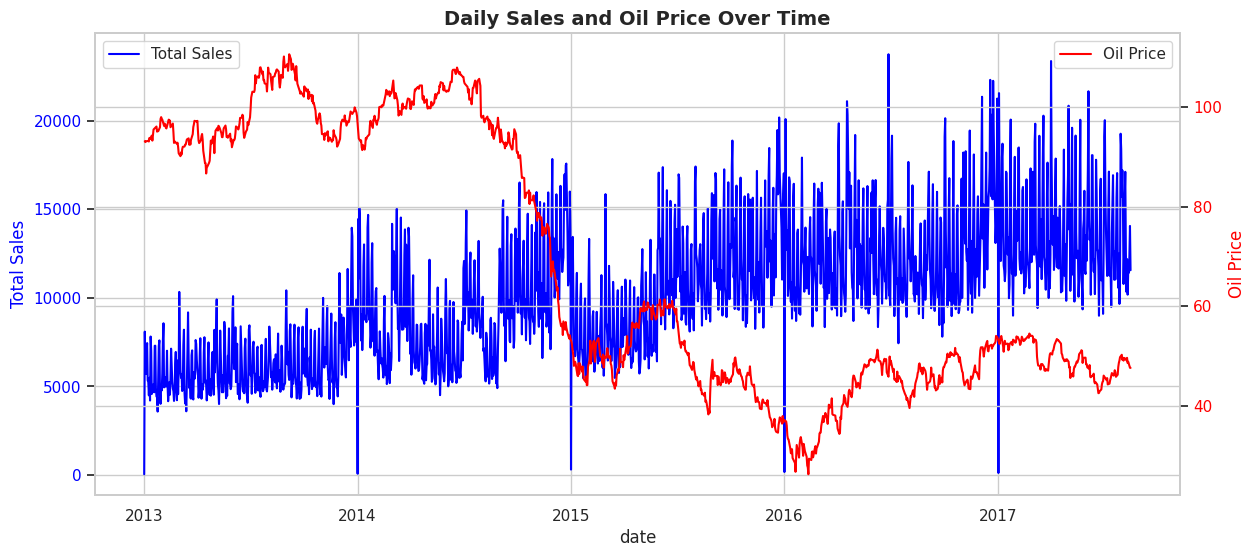

Correlation coefficient: -0.6092


In [44]:
daily_sales = sample_df.groupby('date')['unit_sales'].sum().reset_index()

daily_sales['date'] = pd.to_datetime(daily_sales['date'])
oil_use = oil.copy()
oil_use['date'] = pd.to_datetime(oil_use['date'])
oil_use = oil_use.rename(columns={'dcoilwtico': 'oil_price'})

daily_sales_oil = daily_sales.merge(
    oil_use[['date', 'oil_price']],
    on='date',
    how='left'
)

# Xử lý các ngày giá dầu bị thiếu (do cuối tuần/lễ) bằng nội suy
daily_sales_oil['oil_price'] = daily_sales_oil['oil_price'].interpolate()

fig, axis_left = plt.subplots(figsize=(14, 6))

sns.lineplot(data=daily_sales_oil, x='date', y='unit_sales', ax=axis_left, color='blue', label='Total Sales')
axis_left.set_ylabel('Total Sales', color='blue')
axis_left.tick_params(axis='y', labelcolor='blue')

axis_right = axis_left.twinx()
sns.lineplot(data=daily_sales_oil, x='date', y='oil_price', ax=axis_right, color='red', label='Oil Price')
axis_right.set_ylabel('Oil Price', color='red')
axis_right.tick_params(axis='y', labelcolor='red')

plt.title('Daily Sales and Oil Price Over Time', fontsize=14, fontweight='bold')
plt.show()

corr = daily_sales_oil['unit_sales'].corr(daily_sales_oil['oil_price'])
print(f"Correlation coefficient: {corr:.4f}")

Biểu đồ cho thấy xu hướng biến động giữa doanh số bán hàng (unit_sales) và giá dầu (oil_price) trong giai đoạn 2013 - 2017. Giá dầu (đường đỏ) giảm rất mạnh từ khoảng 100 USD vào năm 2014 xuống gần 30 USD vào đầu năm 2016, sau đó dao động quanh mức 40 - 50 USD trong các năm tiếp theo. Trong khi đó, tổng doanh số bán hàng (đường xanh) lại có xu hướng tăng dần theo thời gian, từ khoảng 300,000 - 500,000 trong năm 2013 lên mức thường xuyên dao động quanh 700,000 - 1,000,000 units vào giai đoạn 2016 - 2017.

Điều đáng chú ý là khi giá dầu giảm mạnh trong giai đoạn 2014 - 2016, doanh số bán hàng không giảm theo mà ngược lại còn tăng lên đáng kể. Ví dụ:
- Năm 2014: giá dầu vẫn quanh mức 90 - 100 USD, doanh số chủ yếu dao động dưới 700,000.
- Đầu năm 2016: giá dầu giảm xuống gần 30 USD, trong khi doanh số nhiều thời điểm vượt 1 triệu.

Điều này cho thấy mối quan hệ giữa giá dầu và doanh số bán lẻ không phải là tương quan tuyến tính trực tiếp. Giá dầu có thể ảnh hưởng gián tiếp đến nền kinh tế thông qua:
- chi phí vận chuyển
- lạm phát
- sức mua người tiêu dùng
- mức chi tiêu hộ gia đình

Khi giá dầu giảm mạnh:
- chi phí vận hành và vận chuyển có thể giảm
- giá hàng hóa ổn định hơn
- người tiêu dùng có thể tăng chi tiêu

-> từ đó hỗ trợ tăng trưởng doanh số bán lẻ

Ngược lại, khi giá dầu tăng mạnh:
- áp lực chi phí logistics tăng
- giá hàng hóa tăng theo
- sức mua thị trường có thể suy giảm

-> tạo ảnh hưởng tiêu cực lên hoạt động bán lẻ trong dài hạn.

Tuy nhiên, doanh số bán lẻ còn chịu tác động mạnh hơn từ: seasonality, promotion, holidays, tăng trưởng hệ thống cửa hàng, và hành vi tiêu dùng theo thời gian.

Insight này cho thấy trong bài toán forecasting, oil_price nên được xem là một external feature hỗ trợ giúp mô hình học được các biến động kinh tế dài hạn thay vì là yếu tố quyết định trực tiếp doanh số.

Từ góc nhìn kinh doanh cho thấy doanh nghiệp không chỉ cần theo dõi dữ liệu bán hàng nội bộ mà còn phải quan tâm đến các yếu tố kinh tế bên ngoài như giá dầu. Biến động mạnh của oil price có thể ảnh hưởng trực tiếp đến: chi phí logistics, chuỗi cung ứng, giá thành sản phẩm, và chiến lược pricing. Việc hiểu được mối quan hệ giữa giá dầu và hành vi tiêu dùng sẽ giúp doanh nghiệp:
- tối ưu kế hoạch nhập hàng
- dự báo chi phí vận hành
- xây dựng chiến lược giá phù hợp
- chủ động thích ứng với các biến động kinh tế trong dài hạn

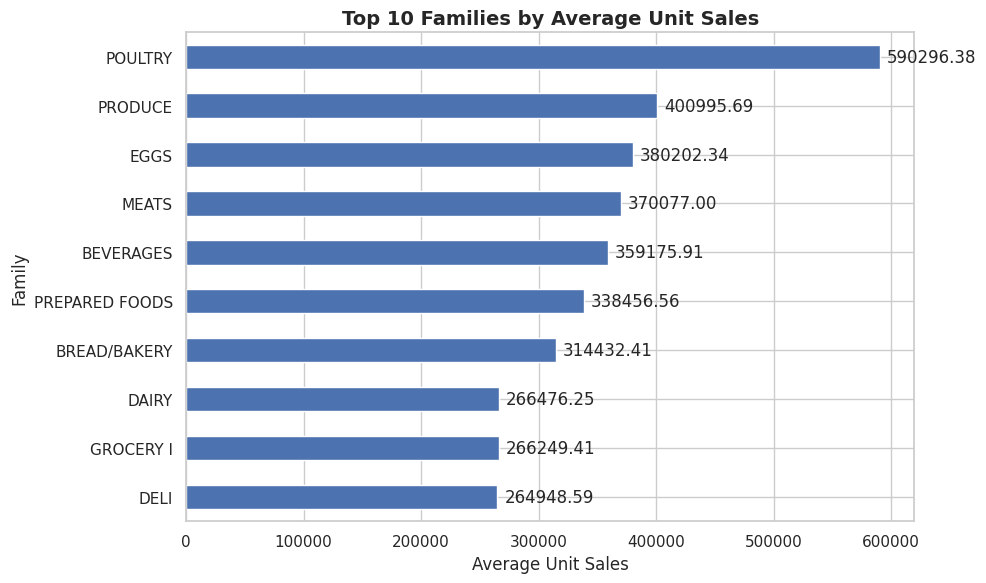

In [18]:
item_sales_full = train.groupby('item_nbr')['unit_sales'].sum().reset_index()

df_combined_full = item_sales_full.merge(items[['item_nbr', 'family']], on='item_nbr', how='left')

family_sales = df_combined_full.groupby('family')['unit_sales'].mean().sort_values(ascending=False)

top_families = family_sales.head(10).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ax = top_families.plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.title("Top 10 Families by Average Unit Sales", fontsize=14, fontweight='bold')
plt.xlabel("Average Unit Sales")
plt.ylabel("Family")                      
plt.tight_layout()
plt.show()

Biểu đồ cho thấy doanh số trung bình phân bố không đồng đều giữa các nhóm sản phẩm và tập trung mạnh vào các mặt hàng thực phẩm thiết yếu. Trong đó, nhóm POULTRY có doanh số trung bình cao nhất với khoảng 590,296 cao vượt trội so với các nhóm còn lại. Đứng thứ hai là PRODUCE với khoảng 400,996 tiếp theo là: EGGS: ~ 380,202, MEATS: ~ 370,077, BEVERAGES: ~ 359,176. Trong khi đó, các nhóm như: DELI (~ 264,949), GROCERY I (~ 266,249), DAIRY (~ 266,476)
có mức doanh số trung bình thấp hơn đáng kể. Chênh lệch giữa nhóm cao nhất (POULTRY) và nhóm thấp nhất trong top 10 (DELI) lên tới hơn 325,000 cho thấy nhu cầu tiêu dùng giữa các nhóm sản phẩm khác nhau rất lớn.

Phản ánh rõ hành vi tiêu dùng trong ngành bán lẻ: các sản phẩm thực phẩm tươi sống và thiết yếu như thịt gia cầm, rau củ, trứng và thịt có nhu cầu ổn định và tần suất mua cao hơn nhiều so với các nhóm sản phẩm khác. Đây là những mặt hàng phục vụ nhu cầu sinh hoạt hàng ngày nên có tốc độ quay vòng lớn và đóng vai trò quan trọng trong tổng doanh thu hệ thống bán lẻ. Ngoài ra, các nhóm như: POULTRY, PRODUCE, MEATS không chỉ có doanh số cao mà còn thường nhạy cảm với: seasonality, holiday demand, biến động giá cả thị trường. Ví dụ:
- nhu cầu thịt và thực phẩm tươi sống thường tăng mạnh vào cuối tuần hoặc dịp lễ
- rau củ và thực phẩm thiết yếu có mức tiêu thụ ổn định quanh năm
- đồ uống (BEVERAGES) dễ tăng mạnh trong mùa nóng hoặc các campaign promotion

Đối với forecasting model, thấy feature family có vai trò cực kỳ quan trọng vì mỗi nhóm sản phẩm có: mức cầu khác nhau, volatility khác nhau, seasonal pattern khác nhau, và mức độ phản ứng với promotion khác nhau. Nếu mô hình không phân biệt hành vi giữa các family, forecasting accuracy sẽ giảm đáng kể, đặc biệt ở các nhóm có demand cao như POULTRY hoặc PRODUCE. Do đó cần:
- encoding family features
- tạo interaction giữa family và promotion
- xây dựng lag features riêng theo từng family
- thậm chí huấn luyện specialized models cho các nhóm sản phẩm lớn

Ngoài ra, biểu đồ cũng cho thấy dữ liệu có khả năng tồn tại hiện tượng demand imbalance giữa các nhóm sản phẩm. Các family có doanh số quá lớn có thể chi phối loss function của mô hình, khiến model học thiên lệch về các nhóm bán chạy và dự báo kém cho các nhóm nhỏ hơn. Đây là lý do cần cân nhắc: weighted loss, log transformation, hoặc hierarchical forecasting.

**Từ góc nhìn kinh doanh** biểu đồ cho thấy các nhóm thực phẩm thiết yếu như POULTRY, PRODUCE, EGGS và MEATS đang đóng vai trò cốt lõi trong doanh thu của hệ thống bán lẻ, với doanh số trung bình cao vượt trội so với các nhóm sản phẩm khác. Điều này cho thấy nhu cầu tiêu dùng của khách hàng tập trung mạnh vào các mặt hàng phục vụ sinh hoạt hằng ngày, vì vậy doanh nghiệp cần ưu tiên quản lý tồn kho, chuỗi cung ứng và forecasting cho các nhóm sản phẩm này để tránh thiếu hàng trong các giai đoạn nhu cầu cao. Đồng thời, việc mỗi nhóm sản phẩm có mức doanh số và hành vi tiêu dùng khác nhau cũng giúp doanh nghiệp xây dựng chiến lược marketing và promotion phù hợp hơn cho từng nhóm thay vì triển khai đồng loạt, từ đó tối ưu doanh thu, chi phí vận hành và hiệu quả kinh doanh tổng thể.

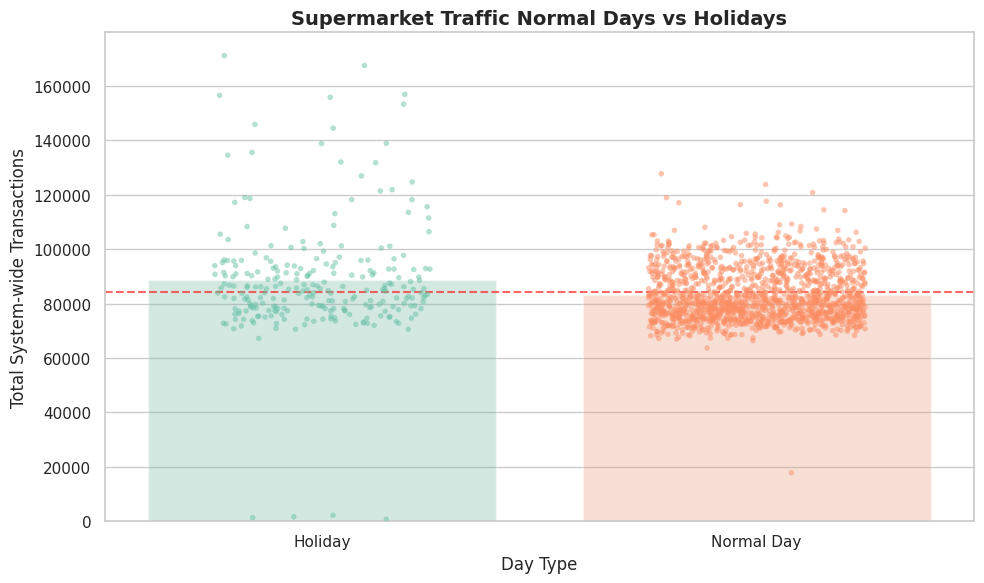

In [19]:
# 1. Tính tổng số giao dịch của toàn hệ thống theo từng ngày từ bảng transactions
daily_tx = transactions.groupby('date')['transactions'].sum().reset_index()

# 2. Lấy danh sách ngày lễ (loại bỏ các ngày bị trùng lặp)
holiday_dates = holidays[['date']].drop_duplicates()
holiday_dates['is_holiday'] = 'Holiday'

# 3. Gộp bảng giao dịch với bảng ngày lễ
tx_holiday_check = daily_tx.merge(holiday_dates, on='date', how='left')

# 4. Những ngày không khớp trúng ngày lễ sẽ được điền là 'Normal Day'
tx_holiday_check['is_holiday'] = tx_holiday_check['is_holiday'].fillna('Normal Day')

plt.figure(figsize=(10, 6))

sns.barplot(
    data=tx_holiday_check, 
    x='is_holiday', 
    y='transactions', 
    hue='is_holiday',
    errorbar=None, 
    alpha=0.3, 
    palette='Set2',
    legend=False
)

# Rải tất cả các ngày thực tế thành các hạt chấm (Mỗi chấm là 1 ngày)
sns.stripplot(
    data=tx_holiday_check, 
    x='is_holiday', 
    y='transactions', 
    hue='is_holiday',
    jitter=0.25, 
    size=4, 
    alpha=0.5, 
    palette='Set2',
    legend=False
)

system_mean = tx_holiday_check['transactions'].mean()
plt.axhline(system_mean, color='red', linestyle='--', alpha=0.6, label='System Average')

plt.title("Supermarket Traffic Normal Days vs Holidays", fontsize=14, fontweight='bold')
plt.xlabel("Day Type")
plt.ylabel("Total System-wide Transactions") 

plt.tight_layout()
plt.show()

Biểu đồ cho thấy số lượng giao dịch trong siêu thị giữa ngày thường và ngày lễ có sự khác biệt khá rõ về mức độ biến động. Mặc dù giá trị trung bình của hai nhóm không chênh lệch quá lớn và đều dao động quanh mức 80,000 - 85,000 transactions, nhưng các ngày lễ (Holiday) xuất hiện nhiều điểm giao dịch đột biến hơn đáng kể. Cụ thể:
- Ở ngày thường (Normal Day), phần lớn giao dịch tập trung trong khoảng 70,000 - 100,000 transactions và ít xuất hiện các giá trị cực lớn.
- Trong khi đó, ở ngày lễ (Holiday), ngoài vùng giao dịch phổ biến khoảng 75,000 - 95,000, còn xuất hiện nhiều spike lớn vượt: 120,000 transactions, 140,000 transactions, thậm chí gần 170,000 transactions. Điều này cho thấy ngày lễ không nhất thiết làm tăng mạnh mức giao dịch trung bình toàn hệ thống, nhưng lại làm tăng đáng kể volatility và khả năng xuất hiện các demand spikes bất thường.

Phản ánh hành vi mua sắm của người tiêu dùng trong các dịp đặc biệt: khách hàng có xu hướng mua sắm tập trung, mua tích trữ, hoặc tăng chi tiêu trước và trong các kỳ nghỉ.

Tuy nhiên, không phải tất cả ngày lễ đều tạo ra lưu lượng khách cao giống nhau, dẫn đến phân phối transactions trong nhóm Holiday phân tán mạnh hơn so với ngày thường.

Đối với forecasting model, đây là biểu đồ rất quan trọng vì nó cho thấy feature holiday có thể không tạo ra mức tăng trung bình lớn, nhưng lại ảnh hưởng mạnh đến: variance, volatility, và extreme demand events. Nếu mô hình không học được holiday effects, khả năng dự báo trong các giai đoạn cao điểm sẽ giảm đáng kể và dễ dẫn đến sai số lớn ở các spike transactions. Vì vậy cần: encode holiday features, phân loại holiday type, tạo feature days_before_holiday, và kết hợp holiday với promotion hoặc weekend features.

**Từ góc nhìn kinh doanh** cho thấy doanh nghiệp cần đặc biệt chú trọng đến khả năng xử lý các đợt tăng đột biến lưu lượng khách trong ngày lễ thay vì chỉ tập trung vào mức trung bình doanh số. Các giai đoạn holiday có thể tạo ra áp lực lớn lên: tồn kho, nhân sự, quầy thanh toán, logistics, và chuỗi cung ứng. Do đó, doanh nghiệp cần chuẩn bị hàng hóa, tăng cường nhân sự vận hành và tối ưu hệ thống cung ứng trước các dịp lễ lớn nhằm tránh tình trạng quá tải hoặc thiếu hàng. Đồng thời, việc hiểu được mức độ biến động của traffic trong ngày lễ cũng giúp doanh nghiệp xây dựng các chiến lược promotion và phân bổ nguồn lực hiệu quả hơn cho từng mùa cao điểm tiêu dùng.

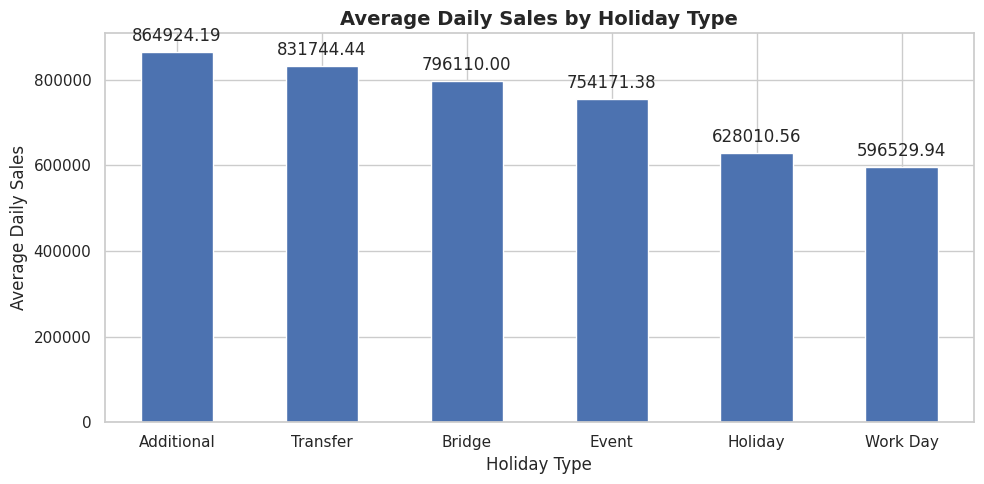

In [20]:
# Bước 1: Tính tổng doanh số theo từng NGÀY trên bảng train gốc
# Lệnh này nén 125 triệu dòng về còn ~1,700 dòng, cực kỳ nhẹ!
daily_sales_full = train.groupby('date')['unit_sales'].sum().reset_index()

# Đảm bảo cột date của cả hai bảng ở cùng định dạng datetime trước khi merge
daily_sales_full['date'] = pd.to_datetime(daily_sales_full['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

# Bước 2: Chỉ lấy các cột cần thiết từ bảng holidays và loại bỏ các dòng trùng ngày 
# (Tránh việc một ngày có nhiều lễ làm phóng đại doanh số)
holiday_types = holidays[['date', 'type']].drop_duplicates(subset=['date'])

# Bước 3: Merge bảng doanh số ngày với bảng loại ngày lễ
df_holiday_type = daily_sales_full.merge(holiday_types, on='date', how='inner')

# Bước 4: Gom nhóm theo 'type' (Loại ngày lễ) để tính doanh số trung bình
holiday_type_sales = df_holiday_type.groupby('type')['unit_sales'].mean().sort_values(ascending=False)

# Bước 5: Trực quan hóa biểu đồ cột (Bar chart) giống hệt cấu trúc của bạn
plt.figure(figsize=(10, 5))
ax = holiday_type_sales.plot(kind='bar')

# Dán nhãn số liệu lên đầu mỗi cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=5)

plt.title('Average Daily Sales by Holiday Type', fontsize=14, fontweight='bold')
plt.xlabel('Holiday Type')
plt.ylabel('Average Daily Sales')
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

Biểu đồ cho thấy doanh số trung bình hằng ngày thay đổi đáng kể theo từng loại ngày lễ. Trong đó, nhóm Additional có doanh số cao nhất với khoảng 864,924, tiếp theo là:
- Transfer: ~831,744
- Bridge: ~796,110
- Event: ~754,171

Trong khi đó Holiday chỉ đạt khoảng 628,011 và Work Day thấp nhất với khoảng 596,530. Điều này cho thấy không phải tất cả các ngày lễ đều tác động giống nhau đến hành vi mua sắm của khách hàng. Các loại ngày như Additional, Transfer hay Bridge thường tạo ra mức doanh số cao hơn rất nhiều so với ngày làm việc thông thường, với mức chênh lệch lên tới gần 270,000 giữa Additional và Work Day.

Biểu đồ này phản ánh rằng người tiêu dùng có xu hướng tăng mạnh hoạt động mua sắm trong các giai đoạn nghỉ kéo dài hoặc các ngày nghỉ được nối lịch (bridge/transfer holidays). Khi có thêm thời gian nghỉ, khách hàng thường: mua sắm tích trữ, tăng chi tiêu cho thực phẩm và nhu yếu phẩm hoặc chuẩn bị cho các dịp tụ họp và lễ hội. Đặc biệt, nhóm Additional đạt doanh số cao nhất cho thấy các ngày nghỉ bổ sung có thể kích thích nhu cầu tiêu dùng mạnh hơn cả holiday thông thường. Điều này có thể đến từ việc người tiêu dùng tận dụng các kỳ nghỉ dài để mua sắm nhiều hơn hoặc các doanh nghiệp thường triển khai promotion mạnh trong các giai đoạn này.

Đối với forecasting model, biểu đồ cho thấy feature holiday_type mang rất nhiều thông tin quan trọng thay vì chỉ sử dụng biến nhị phân đơn giản như: holiday = True/False. Mỗi loại holiday tạo ra mức ảnh hưởng khác nhau lên doanh số, vì vậy việc encode chi tiết: Additional, Transfer, Bridge, Event, Holiday sẽ giúp mô hình học tốt hơn seasonal demand patterns và giảm sai số dự báo trong các dịp đặc biệt.

**Từ góc nhìn kinh doanh** giúp doanh nghiệp xác định rõ các giai đoạn có tiềm năng doanh thu cao nhất để chủ động chuẩn bị hàng tồn kho, tăng cường logistics và phân bổ nhân sự phù hợp. Đồng thời, doanh nghiệp cũng có thể tận dụng các ngày Additional hoặc Transfer để triển khai promotion và chiến dịch marketing nhằm tối đa hóa doanh thu, vì đây là những thời điểm khách hàng có xu hướng chi tiêu mạnh hơn đáng kể so với ngày làm việc thông thường.

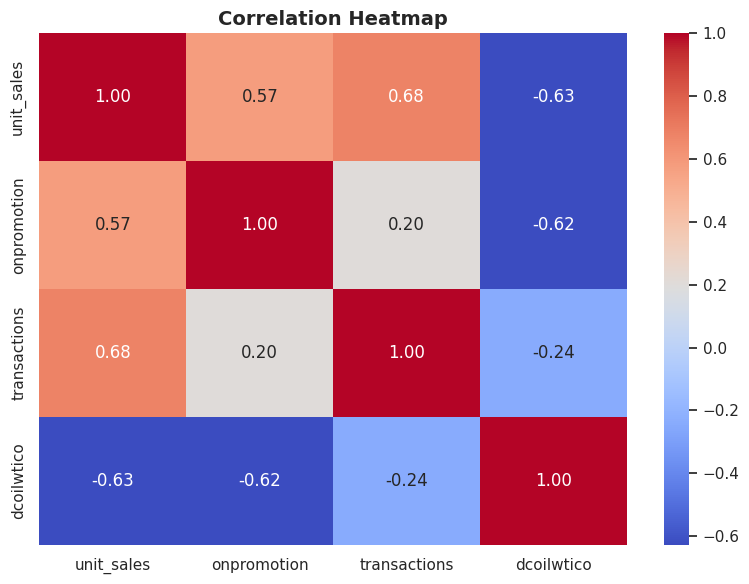

In [21]:
# 1. Đảm bảo cột 'date' của tất cả các bảng phụ đều ở định dạng Datetime chuẩn
oil['date'] = pd.to_datetime(oil['date'])
transactions['date'] = pd.to_datetime(transactions['date'])

# 2. Aggregate theo ngày từ bảng train gốc
daily = train.groupby('date').agg({
    'unit_sales': 'sum',
    'onpromotion': 'sum'
}).reset_index()

# SỬA LỖI: Ép cột 'date' của bảng daily về lại định dạng ngày tháng chuẩn giống bảng oil
daily['date'] = pd.to_datetime(daily['date'])

# 3. Merge thêm bảng oil
daily = daily.merge(
    oil[['date', 'dcoilwtico']],
    on='date',
    how='left'
)

# 4. Tính toán và merge thêm bảng transactions
trans_daily = transactions.groupby('date')['transactions'].sum().reset_index()
trans_daily['date'] = pd.to_datetime(trans_daily['date']) # Đảm bảo đồng bộ định dạng

daily = daily.merge(
    trans_daily,
    on='date',
    how='left'
)

# 5. Điền giá trị trống cho giá dầu (Dùng .ffill() thay cho fillna(method='ffill'))
daily['dcoilwtico'] = daily['dcoilwtico'].ffill()

# 6. Vẽ Ma trận tương quan (Correlation matrix) chuẩn của bạn
corr = daily[['unit_sales', 'onpromotion', 'transactions', 'dcoilwtico']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Biểu đồ correlation heatmap cho thấy mối quan hệ giữa các yếu tố chính ảnh hưởng đến doanh số bán hàng trong hệ thống bán lẻ. Trong đó, **transactions có tương quan dương mạnh nhất với doanh số với hệ số khoảng 0.68**, cho thấy số lượng giao dịch tăng thường đi kèm với doanh số tăng. Điều này phản ánh rằng lưu lượng khách hàng là một trong những yếu tố tác động trực tiếp và mạnh nhất đến hiệu quả bán hàng của hệ thống siêu thị. 

Bên cạnh đó, **onpromotion cũng có tương quan dương khá mạnh với unit_sales ở mức khoảng 0.57**, cho thấy các chương trình promotion có khả năng thúc đẩy doanh số đáng kể. Biểu dồ này phù hợp với các phân tích trước đó khi nhiều nhóm sản phẩm ghi nhận mức tăng doanh số rõ rệt trong các giai đoạn có khuyến mãi. Điều này chứng minh promotion là một công cụ kích cầu rất quan trọng trong hoạt động bán lẻ.

Ngược lại, biến dcoilwtico (giá dầu) lại có tương quan âm khá mạnh với unit_sales (~ -0.63)
và onpromotion (~ -0.62). Điều này cho thấy khi giá dầu tăng, doanh số và hoạt động promotion có xu hướng giảm. Từ góc nhìn kinh doanh, điều này có thể phản ánh ảnh hưởng gián tiếp của giá dầu đến: chi phí vận chuyển, chi phí logistics, giá hàng hóa và sức mua của người tiêu dùng. Khi giá dầu tăng cao, áp lực chi phí vận hành và lạm phát có thể khiến doanh nghiệp giảm cường độ promotion hoặc người tiêu dùng thắt chặt chi tiêu hơn, từ đó làm giảm doanh số bán hàng.

Ngoài ra, transactions và onpromotion chỉ có tương quan khoảng 0.20, cho thấy promotion không nhất thiết làm tăng mạnh số lượng khách hàng đến siêu thị mà có thể chủ yếu làm tăng giá trị mua sắm hoặc số lượng sản phẩm trên mỗi giao dịch. Đây là một insight rất quan trọng vì nó cho thấy promotion có thể đang tác động nhiều hơn đến hành vi chi tiêu của khách hàng hiện tại thay vì thu hút thêm lượng lớn khách hàng mới.

Đối với forecasting model, biểu đồ này cho thấy: transactions, onpromotion và dcoilwtico đều là các feature quan trọng cần được giữ lại trong pipeline vì chúng mang tín hiệu khác nhau về hành vi tiêu dùng và điều kiện thị trường. Trong đó:
- transactions phản ánh nhu cầu thực tế
- promotion phản ánh hoạt động kích cầu
- oil price phản ánh yếu tố kinh tế vĩ mô bên ngoài.

**Từ góc nhìn kinh doanh** giúp doanh nghiệp hiểu rõ hơn đâu là các yếu tố ảnh hưởng mạnh nhất đến doanh số để tối ưu chiến lược vận hành. Việc tăng traffic khách hàng và triển khai promotion hiệu quả có thể tạo tác động trực tiếp đến tăng trưởng doanh thu. Đồng thời, doanh nghiệp cũng cần theo dõi các biến động kinh tế như giá dầu để chủ động điều chỉnh chiến lược pricing, logistics và marketing nhằm giảm thiểu rủi ro trong các giai đoạn thị trường biến động mạnh.

# **Item Analysis**

In [22]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4100 entries, 0 to 4099
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   item_nbr    4100 non-null   int64 
 1   family      4100 non-null   object
 2   class       4100 non-null   int64 
 3   perishable  4100 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 128.3+ KB


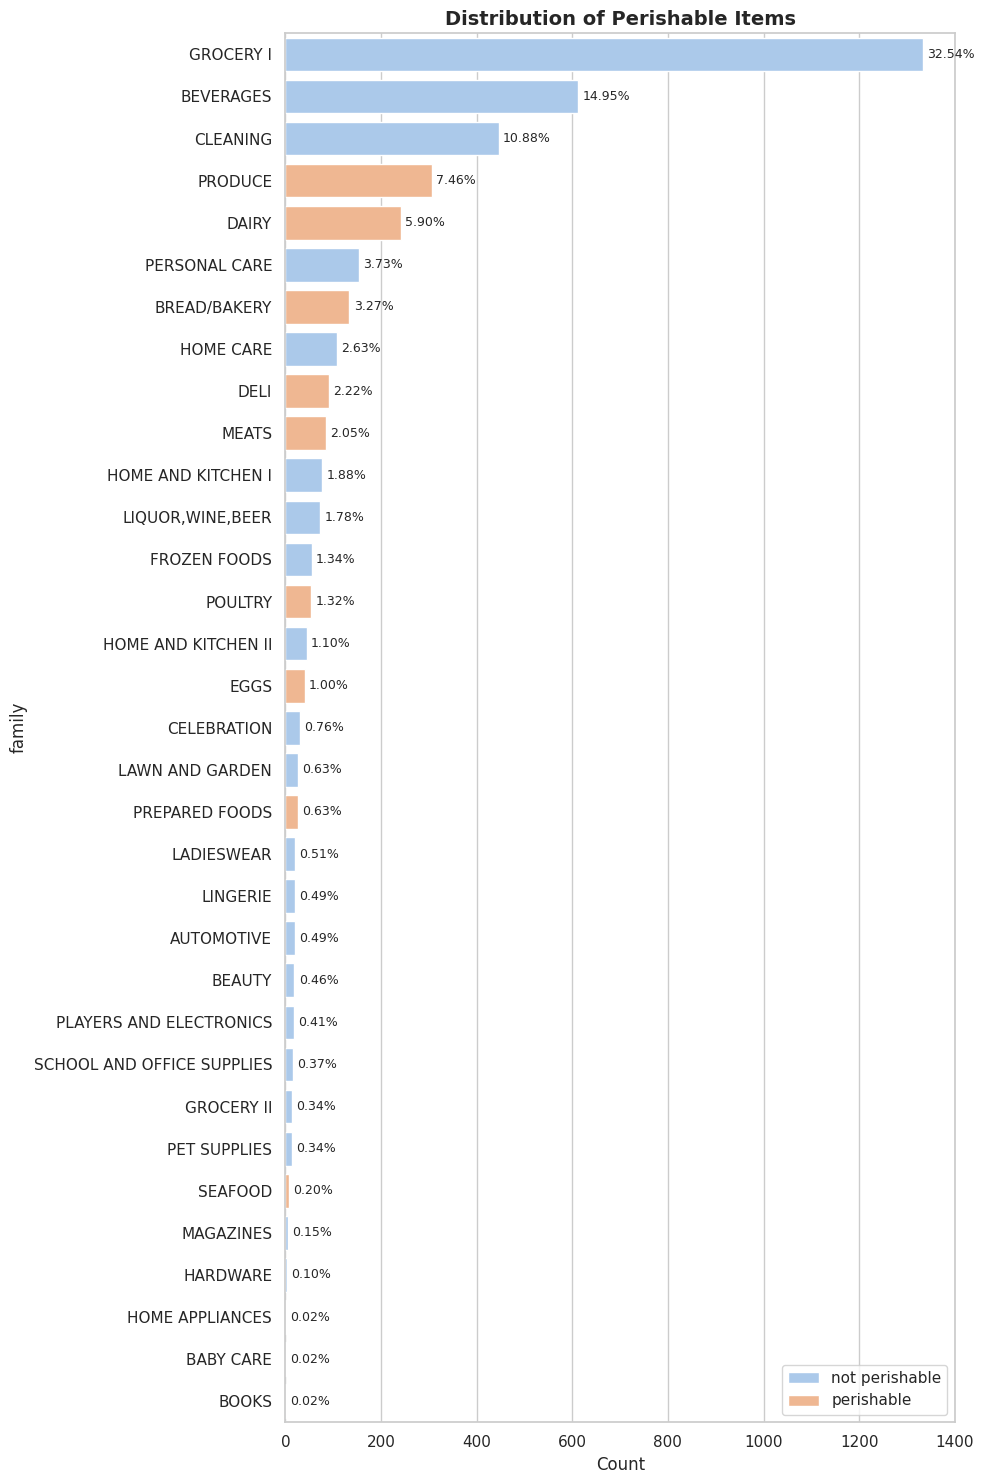

In [23]:
colName = "family"

sns.set_theme(style="whitegrid")
val = items[colName].value_counts().sort_values(ascending=False)
summ = val.sum() 

plt.figure(figsize=(10, 15))

ax = sns.countplot(data=items, y=colName, palette="pastel", hue="perishable", order=val.index)

# Vòng lặp xử lý từng nhóm cột (not perishable và perishable)
for container in ax.containers:
    # Tính % trực tiếp cho từng cột dựa trên chiều rộng (get_width)
    # Thêm điều kiện 'if v > 0' để tránh hiển thị 0.0% ở những cột trống
    labels = [f'{(v / summ * 100):.2f}%' if (v := p.get_width()) > 0 else '' for p in container]
    
    # Gán nhãn bằng list labels vừa tạo
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.legend(["not perishable", "perishable"], loc='lower right')
plt.title("Distribution of Perishable Items", fontsize=14, fontweight='bold')
plt.xlabel("Count")
plt.ylabel(colName)

plt.tight_layout()
plt.show()

Biểu đồ cho thấy sự phân bố giữa các nhóm sản phẩm dễ hỏng (perishable) và không dễ hỏng (not perishable) trong hệ thống bán lẻ là rất không đồng đều. Nhóm **GROCERY I chiếm tỷ trọng lớn nhất với khoảng 32.54% tổng số sản phẩm**, vượt xa tất cả các nhóm còn lại và chủ yếu thuộc nhóm không dễ hỏng. 

Tiếp theo là: BEVERAGES (~ 14.95%), CLEANING (~ 10.88%) đây đều là các nhóm sản phẩm có thời gian bảo quản dài và nhu cầu tiêu dùng ổn định. Điều này phản ánh rằng phần lớn danh mục sản phẩm của hệ thống bán lẻ tập trung vào các mặt hàng tiêu dùng thường xuyên, có vòng đời dài và ít rủi ro hư hỏng. 

Trong khi đó, các nhóm sản phẩm dễ hỏng như: PRODUCE (~ 7.46%), DAIRY (~ 5.90%), MEATS, POULTRY, SEAFOOD chiếm tỷ trọng nhỏ hơn đáng kể nhưng lại mang đặc điểm kinh doanh hoàn toàn khác. Đây là các nhóm sản phẩm có:
shelf-life ngắn, demand volatility cao và rủi ro tồn kho lớn hơn nhiều so với non-perishable items. 

Mặc dù tỷ trọng không quá lớn, các nhóm perishable lại thường đóng vai trò rất quan trọng trong doanh thu và trải nghiệm khách hàng vì đây là các mặt hàng thiết yếu được mua thường xuyên.

Biểu đồ này phản ánh rõ sự khác biệt trong chiến lược vận hành giữa hai loại sản phẩm: 
- Non-perishable items giúp duy trì nguồn doanh thu ổn định và dễ quản lý tồn kho.
- Perishable items yêu cầu forecasting chính xác hơn vì chỉ cần dự báo sai một lượng nhỏ cũng có thể dẫn đến: thiếu hàng, hư hỏng hoặc lãng phí tồn kho rất lớn.

Đối với forecasting model, feature perishable là cực kỳ quan trọng vì hành vi bán hàng giữa hai nhóm sản phẩm này khác nhau rõ rệt. Các sản phẩm perishable thường: nhạy cảm hơn với holidays, promotion, thời tiết và seasonality. Ngoài ra, demand của nhóm này thường biến động mạnh hơn theo ngày và có độ decay cao hơn nếu tồn kho quá lâu. Điều này cho thấy mô hình forecasting cần:
- phân biệt rõ perishable/non-perishable
- xây dựng lag features riêng
- áp dụng weighted training cho nhóm perishable vì sai số dự báo ở các sản phẩm này gây tổn thất kinh doanh lớn hơn.

**Từ góc nhìn kinh doanh** giúp doanh nghiệp hiểu rằng mặc dù nhóm non-perishable chiếm phần lớn danh mục sản phẩm và mang lại sự ổn định trong vận hành, nhưng các sản phẩm perishable mới là nhóm cần được quản lý chặt chẽ nhất trong forecasting và supply chain. Doanh nghiệp cần tối ưu replenishment cycle, tồn kho, logistics lạnh và promotion timing cho các nhóm sản phẩm dễ hỏng nhằm giảm waste, hạn chế stock - out và tối đa hóa lợi nhuận. Đồng thời, việc hiểu rõ tỷ trọng từng family cũng giúp doanh nghiệp phân bổ nguồn lực và chiến lược vận hành phù hợp hơn cho từng nhóm sản phẩm trong hệ thống bán lẻ.

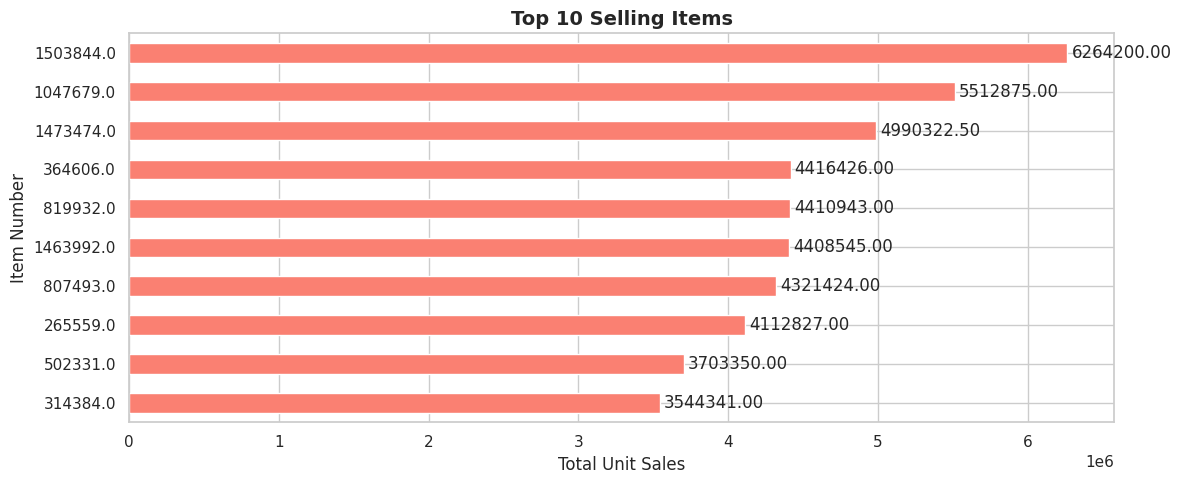

In [24]:
top_items = train.groupby('item_nbr')['unit_sales'].sum().nlargest(10)

plt.figure(figsize=(12, 5))
ax = top_items.sort_values().plot(kind='barh', color='salmon')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title('Top 10 Selling Items', fontsize=14, fontweight='bold')
plt.ylabel('Item Number')
plt.xlabel('Total Unit Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Biểu đồ cho thấy doanh số bán hàng tập trung rất mạnh vào một số ít sản phẩm nổi bật trong hệ thống bán lẻ. Item có doanh số cao nhất đạt khoảng 6.26 triệu, trong khi các item còn lại trong top 10 dao động từ khoảng 3.54 triệu đến 5.51 triệu. Chênh lệch hơn 2.7 triệu giữa item đứng đầu và item cuối top 10 cho thấy mức độ không đồng đều rất lớn trong nhu cầu tiêu dùng giữa các sản phẩm.

Từ góc nhìn kinh doanh cho thấy doanh nghiệp cần ưu tiên đặc biệt cho nhóm sản phẩm bán chạy nhất vì đây là các item ảnh hưởng trực tiếp đến doanh thu toàn hệ thống. Việc forecasting chính xác, tối ưu tồn kho và đảm bảo nguồn cung ổn định cho các sản phẩm này quan trọng hơn rất nhiều so với các item có demand thấp. Đồng thời, doanh nghiệp cũng có thể tập trung promotion, tối ưu trưng bày và chiến lược pricing cho các top-selling items nhằm tối đa hóa doanh thu và duy trì lợi thế cạnh tranh trong hệ thống bán lẻ.

# **Store Analysis**

In [25]:
def show_countplot(store, colName: str):
    sns.set_theme(style="whitegrid")
    
    # Tính toán giá trị để sắp xếp và tính tổng
    val = store[colName].value_counts().sort_values(ascending=False)
    summ = val.sum()

    plt.figure(figsize=(10, len(val) * 0.5 + 2)) 

    ax = sns.countplot(data=store, y=colName, palette="pastel", order=val.index)

    for container in ax.containers:
        # Lấy giá trị v (width) của từng cột để tính % dựa trên tổng summ
        labels = [f'{(v / summ * 100):.2f}%' if (v := p.get_width()) > 0 else '' for p in container]
        
        # Dán nhãn vào biểu đồ
        ax.bar_label(container, labels=labels, padding=5)

    plt.title(f"Distribution of {colName} (%)", fontsize=14, fontweight='bold')
    plt.xlabel("Count")
    plt.ylabel(colName)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_57/3668201975.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=store, y=colName, palette="pastel", order=val.index)


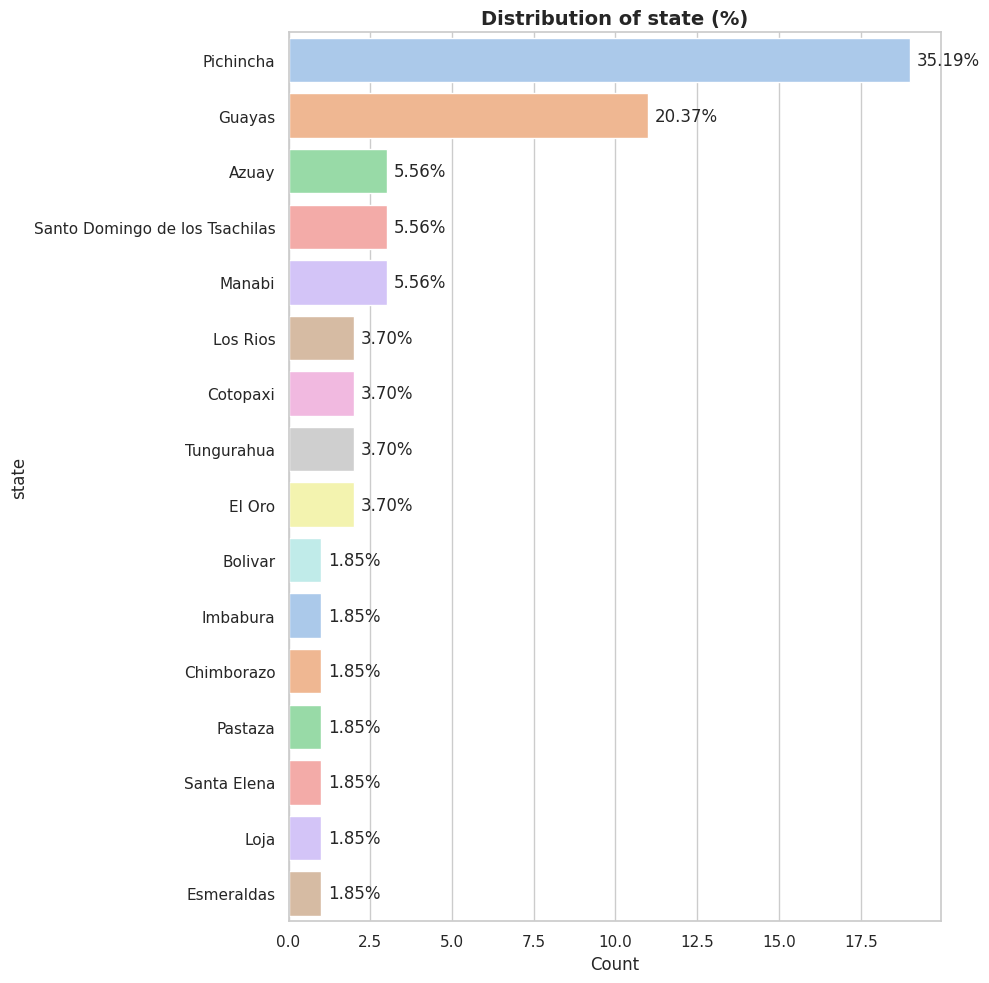

In [26]:
show_countplot(stores, "state")

/tmp/ipykernel_57/3668201975.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=store, y=colName, palette="pastel", order=val.index)


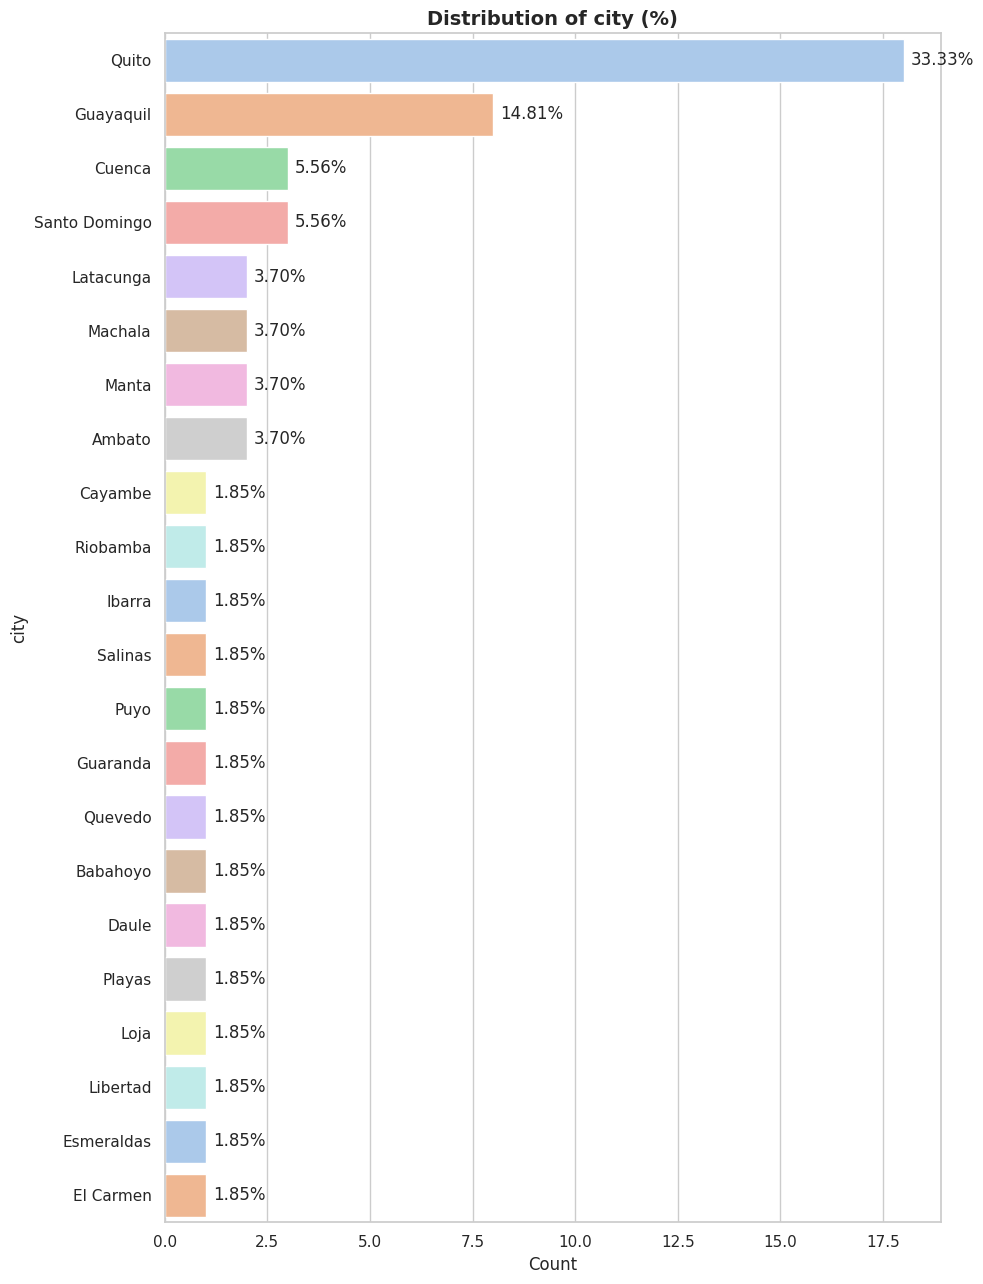

In [27]:
show_countplot(stores, "city")

/tmp/ipykernel_57/3668201975.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=store, y=colName, palette="pastel", order=val.index)


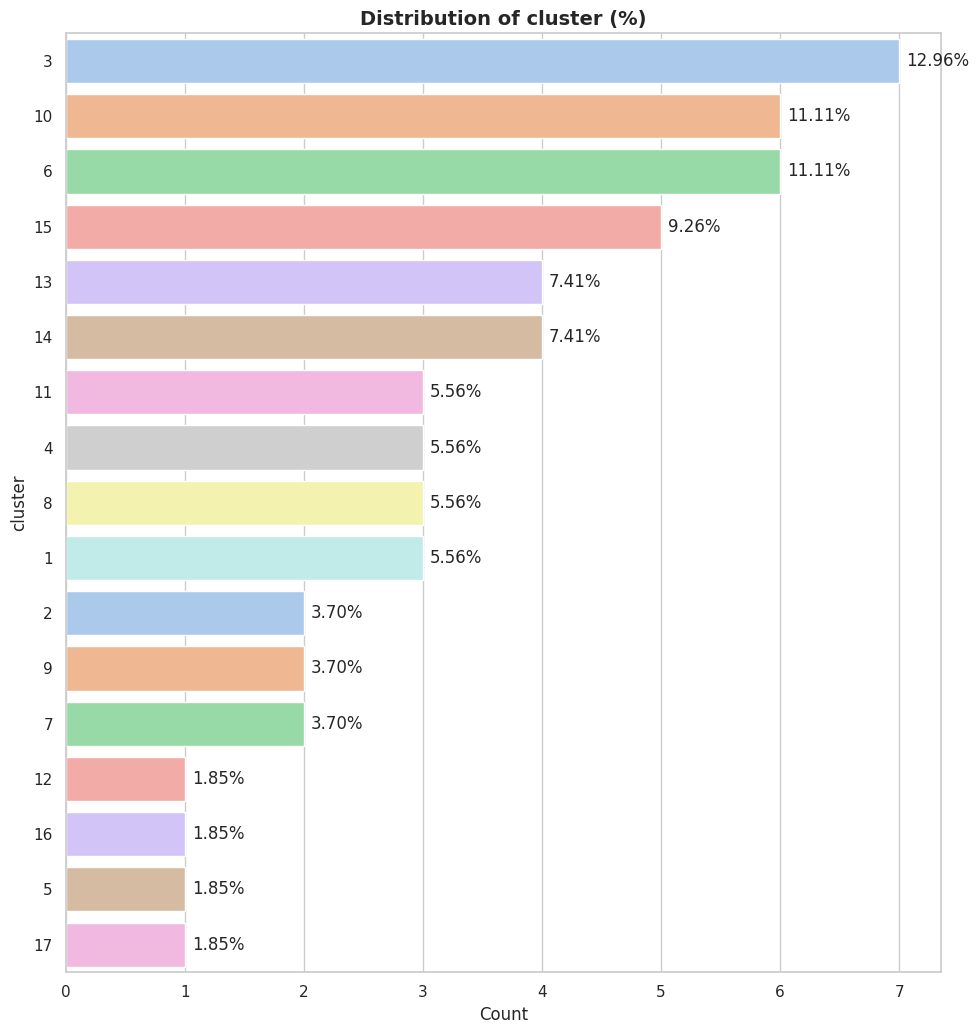

In [28]:
show_countplot(stores, "cluster")

/tmp/ipykernel_57/3668201975.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=store, y=colName, palette="pastel", order=val.index)


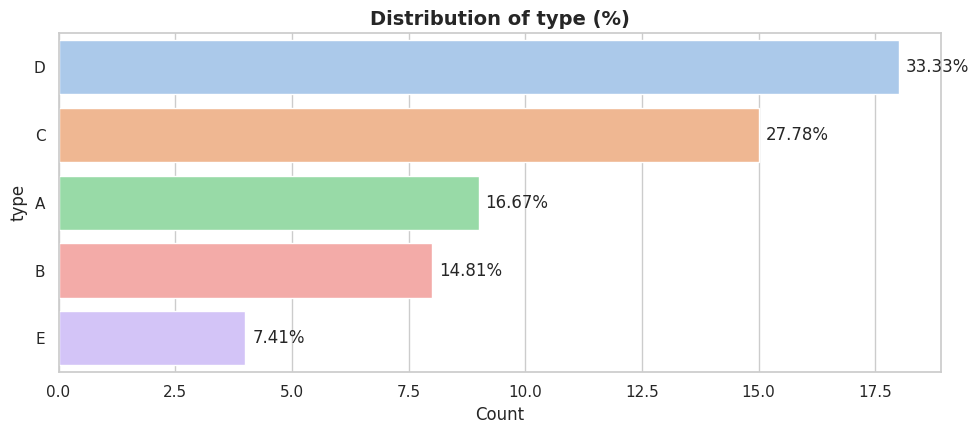

In [29]:
show_countplot(stores, "type")

Bốn biểu đồ cho thấy hệ thống cửa hàng của doanh nghiệp có sự tập trung rất rõ theo cả vị trí địa lý (state, city) và đặc điểm vận hành (cluster, type). Điều này phản ánh chiến lược mở rộng không đồng đều mà tập trung mạnh vào các khu vực và mô hình cửa hàng có tiềm năng doanh thu cao nhất.

**Về mặt địa lý** hệ thống cửa hàng tập trung chủ yếu tại các trung tâm kinh tế lớn của Ecuador. Bang Pichincha chiếm khoảng 35.19% tổng số cửa hàng trong khi thành phố Quito riêng lẻ đã chiếm khoảng 33.33% toàn hệ thống. Bên cạnh đó, Guayas và Guayaquil cũng đóng vai trò rất quan trọng với tỷ trọng lần lượt khoảng 20.37% và 14.81%. Chỉ riêng các khu vực này đã chiếm hơn một nửa số lượng cửa hàng, cho thấy doanh nghiệp đang ưu tiên mở rộng tại những nơi có: mật độ dân số cao, sức mua lớn, hạ tầng thương mại phát triển và nhu cầu tiêu dùng mạnh. Điều này giúp doanh nghiệp tối ưu: logistics, chi phí phân phối, chuỗi cung ứng và khả năng triển khai promotion quy mô lớn.

Tuy nhiên, mức độ tập trung cao vào một số khu vực trọng điểm cũng tạo ra rủi ro phụ thuộc thị trường. Nếu nhu cầu tiêu dùng hoặc tình hình kinh tế tại Quito hay Guayaquil biến động mạnh, doanh thu toàn hệ thống có thể bị ảnh hưởng đáng kể. 

Ngoài yếu tố địa lý, **biểu đồ cluster** cho thấy các cửa hàng được phân bổ theo nhiều cụm khác nhau nhưng không đồng đều. Một số cluster như: Cluster 3 (~ 12.96%), Cluster 10 và 6 (~ 11.11%) chiếm tỷ trọng lớn hơn đáng kể so với nhiều cluster khác chỉ khoảng 1.85% – 3.70%. Điều này cho thấy doanh nghiệp đang tập trung vào một số mô hình vận hành hoặc nhóm khách hàng nhất định có hiệu quả kinh doanh cao hơn. Các cluster nhiều khả năng phản ánh:
- mức thu nhập khu vực
- hành vi tiêu dùng
- quy mô cửa hàng
- mô hình bán lẻ khác nhau

Bên cạnh đó, **phân bố theo store type** cũng cho thấy hệ thống nghiêng mạnh về các loại cửa hàng: Type D (~ 33.33%), Type C (~ 27.78%) trong khi các loại như Type E chỉ chiếm khoảng 7.41%. Biểu đồ này phản ánh doanh nghiệp đang ưu tiên các mô hình cửa hàng phù hợp với:
- khu vực đông dân
- lưu lượng khách cao
- khả năng tạo doanh thu lớn hơn

**Góc nhìn kinh doanh** có thể thấy toàn bộ các biểu đồ cho thấy doanh nghiệp đang áp dụng chiến lược: tập trung nguồn lực vào các khu vực và mô hình cửa hàng mang lại hiệu quả cao nhất thay vì mở rộng đồng đều trên toàn hệ thống.

**Chiến lược này giúp:** tối ưu vận hành, tăng hiệu quả logistics, giảm chi phí quản lý và tối đa hóa doanh thu tại các thị trường trọng điểm.

Tuy nhiên cũng cho thấy **nhu cầu xây dựng chiến lược forecasting và vận hành riêng cho từng: khu vực, cluster và store type.** Bởi hành vi tiêu dùng giữa các thành phố, nhóm khách hàng và mô hình cửa hàng có thể khác nhau rất lớn về:
- seasonal demand
- promotion response
- traffic pattern
- purchasing power

Do đó, việc sử dụng một mô hình forecasting chung cho toàn hệ thống có thể không đủ hiệu quả. Thay vào đó, doanh nghiệp nên: segment forecasting theo cluster hoặc store type, tối ưu tồn kho theo khu vực và triển khai promotion phù hợp cho từng nhóm cửa hàng để cải thiện forecasting accuracy và tối ưu hiệu quả kinh doanh toàn hệ thống.

<Figure size 500x500 with 0 Axes>

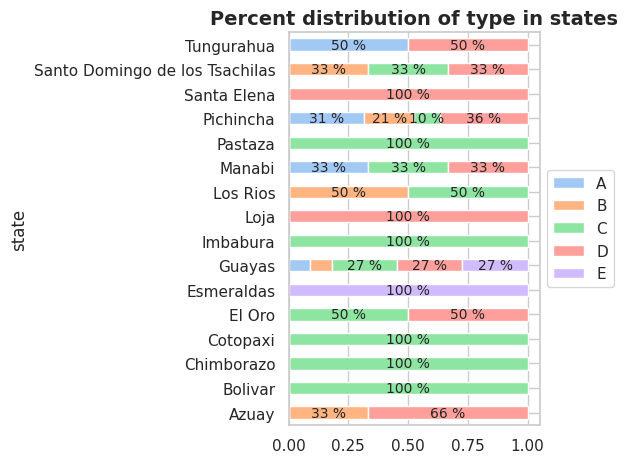

In [30]:
df = stores
x_var= "state"
y_var= "type"

plt.figure(figsize=(5, 5))
df_grouped = df.groupby(x_var)[y_var].value_counts(normalize=True).unstack(y_var)
df_grouped=df_grouped.fillna(0)
colorr=sns.color_palette("pastel",n_colors=df_grouped.shape[1])
df_grouped.plot.barh(stacked=True,color=colorr )

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
for ix, row in df_grouped.reset_index(drop=True).iterrows():
    cumulative = 0
    for element in row:
        if element == element and element > 0.1 and (element is not None):
            plt.text(
                cumulative + element / 2,

                ix,
                f"{int(element * 100)} %",
                va="center",
                ha="center",
                fontsize=10,
            )
        cumulative += element
plt.title("Percent distribution of type in states", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Biểu đồ cho thấy chiến lược triển khai loại cửa hàng giữa các bang có sự khác biệt rất rõ rệt. Một số bang như: Bolivar, Chimborazo, Cotopaxi, Imbabura, Pastaza gần như chỉ sử dụng duy nhất Type C (100%), cho thấy doanh nghiệp đang áp dụng mô hình cửa hàng tiêu chuẩn hóa tại các khu vực nhỏ nhằm tối ưu vận hành và giảm chi phí quản lý.

Ngược lại, các bang lớn như Pichincha, Guayas lại có cơ cấu store type đa dạng hơn nhiều với sự xuất hiện của nhiều loại cửa hàng khác nhau. Điều này phản ánh rằng tại các thị trường lớn, doanh nghiệp cần nhiều mô hình cửa hàng để phục vụ các nhóm khách hàng và nhu cầu tiêu dùng đa dạng hơn.

Từ góc nhìn kinh doanh, có thể thấy doanh nghiệp đang áp dụng chiến lược:
- standardization ở thị trường nhỏ
- diversification ở thị trường lớn.

Điều này giúp tối ưu hiệu quả vận hành tại từng khu vực thay vì sử dụng cùng một mô hình cửa hàng cho toàn bộ hệ thống bán lẻ.

# **Oil Analysis**

In [31]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1218 non-null   datetime64[ns]
 1   dcoilwtico  1175 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 19.2 KB


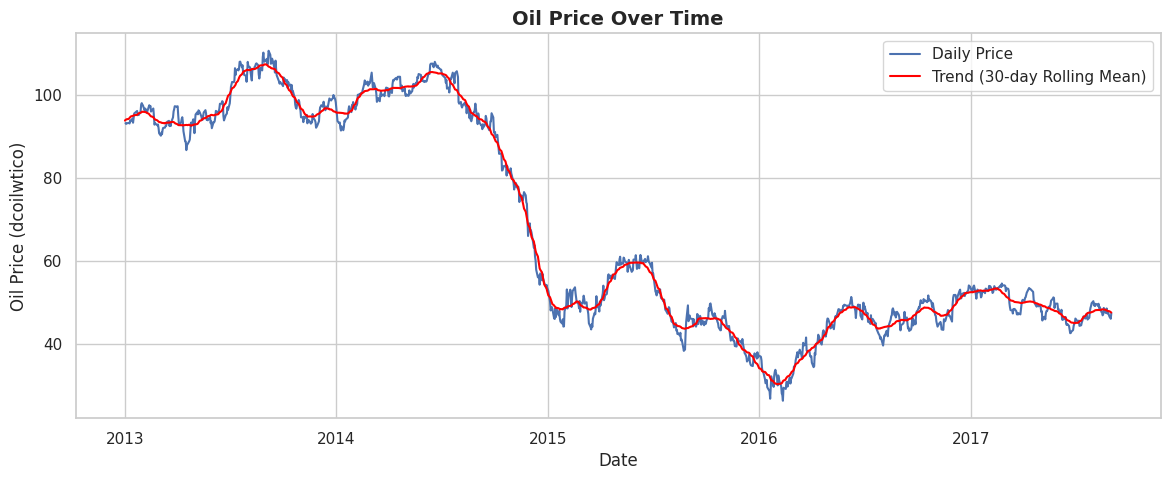

In [32]:
# =====================================================================
# BIỂU ĐỒ 1: Giá dầu theo thời gian (Sử dụng Rolling Mean thay cho LOESS)
# =====================================================================
plt.figure(figsize=(14, 5))

# 1. Vẽ đường dữ liệu gốc
sns.lineplot(data=oil, x="date", y="dcoilwtico", label="Daily Price")

# 2. Tạo đường xu hướng mượt bằng Trung bình trượt (ví dụ: cửa sổ 30 ngày)
# Bạn có thể đổi window=30 thành 60 hoặc 90 tùy thuộc vào độ mượt bạn muốn
oil['oil_trend'] = oil['dcoilwtico'].rolling(window=30, center=True, min_periods=1).mean()

# 3. Vẽ đường xu hướng màu đỏ
sns.lineplot(data=oil, x="date", y="oil_trend", color="red", label="Trend (30-day Rolling Mean)")

plt.title("Oil Price Over Time", fontsize=14, fontweight='bold')
plt.ylabel("Oil Price (dcoilwtico)")
plt.xlabel("Date")
plt.legend()
plt.show()

Biểu đồ cho thấy giá dầu có sự biến động rất mạnh trong giai đoạn 2013–2017 và xuất hiện một “structural break” rõ rệt từ cuối năm 2014. Trong giai đoạn 2013–2014, giá dầu duy trì ở mức cao khoảng 90 - 110 USD/thùng, tuy nhiên sau đó giảm mạnh xuống gần 30 USD/thùng vào đầu năm 2016 trước khi phục hồi nhẹ quanh mức 45 - 55 USD/thùng trong các năm tiếp theo.

Điều này phản ánh thị trường dầu mỏ có volatility rất cao và chịu ảnh hưởng mạnh từ các biến động kinh tế toàn cầu. Ngoài ra, sự thay đổi mạnh về xu hướng giá dầu cũng cho thấy dữ liệu kinh tế trong bài toán forecasting không hoàn toàn stationary theo thời gian mà tồn tại các giai đoạn biến động lớn (economic regime changes).

Từ góc nhìn kinh doanh và forecasting, biểu đồ này cho thấy oil price có thể đóng vai trò như một external macroeconomic signal giúp mô hình học được: các giai đoạn economic shock, thay đổi sức mua thị trường, biến động chi phí logistics và thay đổi hành vi tiêu dùng trong dài hạn. Do đó, feature liên quan đến oil price có thể hữu ích trong việc cải thiện khả năng dự báo ở các giai đoạn thị trường biến động mạnh thay vì chỉ phản ánh mối quan hệ trực tiếp với doanh số bán hàng.

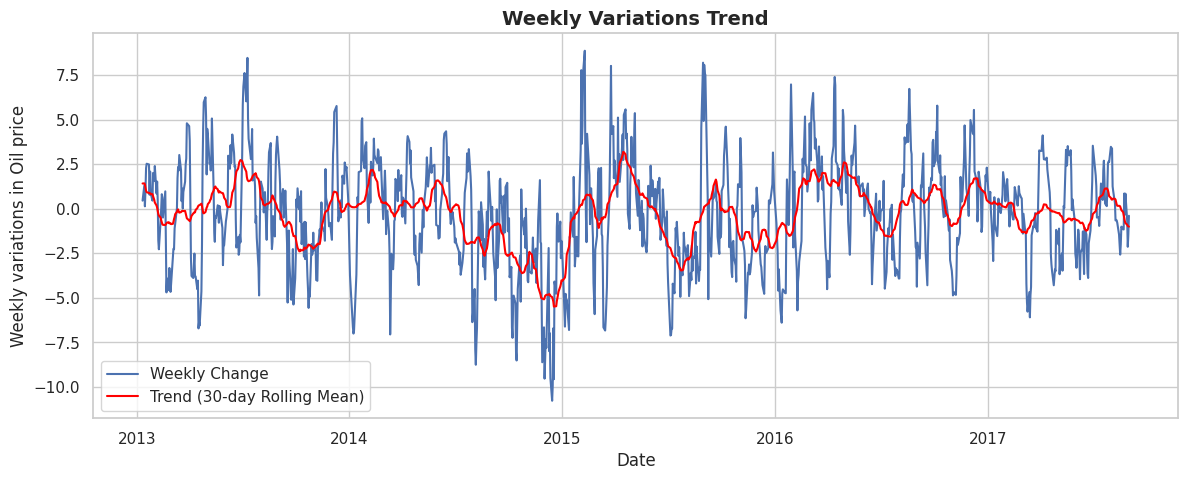

In [33]:
# =====================================================================
# BIỂU ĐỒ 2: Biến động giá dầu hàng tuần (p2) - KHÔNG DÙNG STATSMODELS
# =====================================================================

# 1. Xử lý dữ liệu: sử dụng tên cột đúng là 'dcoilwtico' thay vì 'oilprice'
oil["lag7"] = oil["dcoilwtico"].shift(7)
oil["diff"] = oil["dcoilwtico"] - oil["lag7"]
oil_diff = oil.dropna(subset=["diff"]).copy() # .copy() để tránh cảnh báo SettingWithCopyWarning

plt.figure(figsize=(14, 5))

# 2. Vẽ đường biến động gốc (màu đen)
sns.lineplot(data=oil_diff, x="date", y="diff", label="Weekly Change")

# 3. Tính toán đường xu hướng mượt bằng Trung bình trượt (Ví dụ: cửa sổ 30 ngày)
oil_diff['diff_trend'] = oil_diff['diff'].rolling(window=30, center=True, min_periods=1).mean()

# 4. Vẽ đường xu hướng (màu đỏ)
sns.lineplot(data=oil_diff, x="date", y="diff_trend", color="red", label="Trend (30-day Rolling Mean)")

plt.title("Weekly Variations Trend", fontsize=14, fontweight='bold')
plt.ylabel("Weekly variations in Oil price")
plt.xlabel("Date")
plt.legend()
plt.show()

Biểu đồ cho thấy mức biến động tuần của giá dầu thay đổi liên tục và có volatility khá cao trong toàn bộ giai đoạn 2013–2017. Các biến động ngắn hạn thường dao động quanh mức ±2 đến ±5, tuy nhiên tại một số thời điểm xuất hiện các spike rất lớn vượt quá: +7 hoặc giảm xuống dưới -10. Đặc biệt trong giai đoạn cuối 2014 đến đầu 2015 thời điểm thị trường dầu mỏ bắt đầu bước vào giai đoạn sụt giảm mạnh. 

Đường xu hướng trung bình trượt 30 ngày (đường đỏ) cho thấy: giai đoạn 2014 - 2015 có biến động âm kéo dài, sau đó thị trường chuyển sang trạng thái dao động thất thường hơn trong giai đoạn 2016–2017.

Biểu đồ này hản ánh rằng giá dầu không chỉ thay đổi về xu hướng dài hạn mà còn có mức biến động ngắn hạn rất mạnh theo thời gian. Điều này cho thấy dữ liệu oil price chứa: nhiều noise, volatility và shock bất thường.

Từ góc nhìn forecasting, đặc điểm này rất quan trọng vì: các biến external feature có volatility cao thường khó học hơn và tác động của chúng lên demand có thể không xuất hiện ngay lập tức mà tồn tại dưới dạng lag effect theo thời gian.

Do đó, thay vì sử dụng raw oil price trực tiếp, mô hình forecasting có thể cải thiện hiệu quả bằng cách: sử dụng rolling mean, smoothing, lag features hoặc oil trend indicators để giảm noise và giúp mô hình học được xu hướng kinh tế ổn định hơn thay vì các biến động ngắn hạn ngẫu nhiên.

# **Holidays Analysis**

In [35]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         350 non-null    datetime64[ns]
 1   type         350 non-null    object        
 2   locale       350 non-null    object        
 3   locale_name  350 non-null    object        
 4   description  350 non-null    object        
 5   transferred  350 non-null    bool          
dtypes: bool(1), datetime64[ns](1), object(4)
memory usage: 14.1+ KB


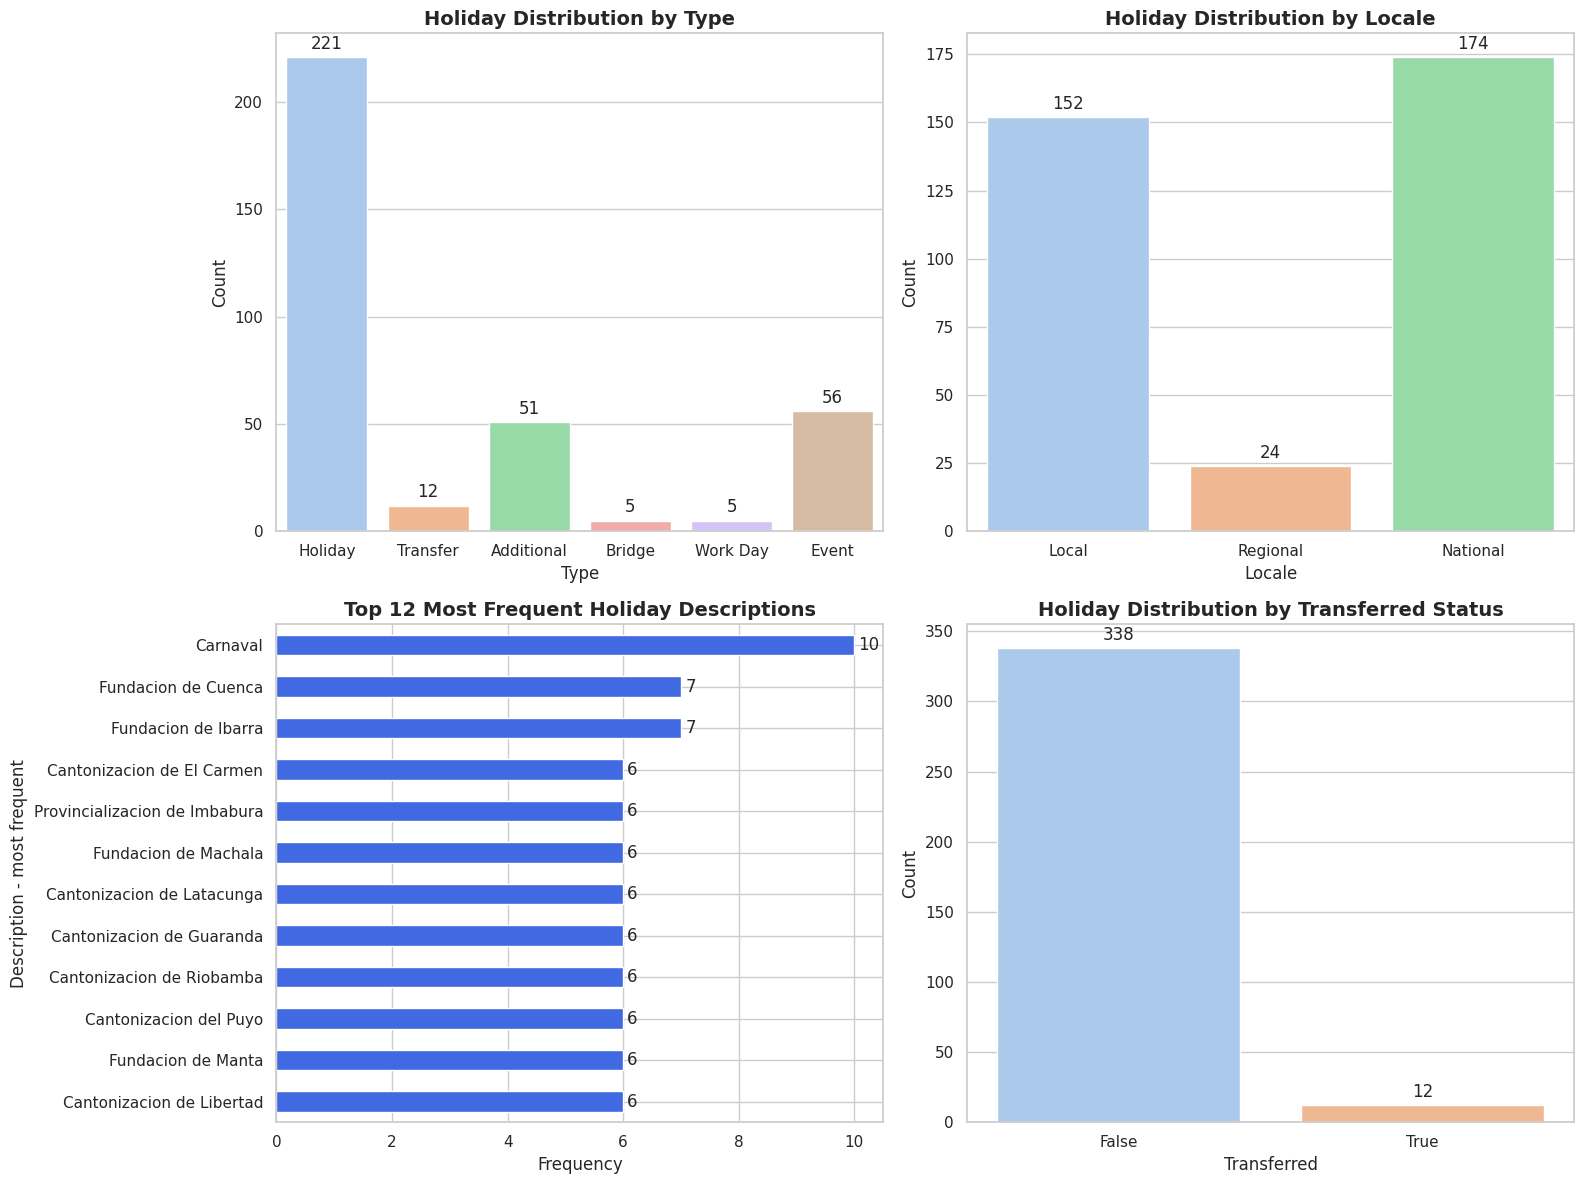

In [37]:
sns.set_theme(style="whitegrid")

# Giả định bạn đã đọc dữ liệu vào DataFrame tên là 'holidays'
# holidays = pd.read_csv("path_to_holidays.csv")

# Khởi tạo lưới biểu đồ 2 dòng, 2 cột
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# -----------------------------------------------------------------
# p1: Phân phối theo 'type' (Biểu đồ cột đứng)
# -----------------------------------------------------------------
sns.countplot(data=holidays, x="type", hue="type", palette="pastel", ax=ax1, legend=False)
ax1.set_title("Holiday Distribution by Type", fontsize=14, fontweight='bold')
ax1.set_xlabel("Type")
ax1.set_ylabel("Count")
# Thêm nhãn số đếm trên đầu cột
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.0f", padding=3)

# -----------------------------------------------------------------
# p2: Phân phối theo 'locale' (Biểu đồ cột đứng)
# -----------------------------------------------------------------
sns.countplot(data=holidays, x="locale", hue="locale", palette="pastel", ax=ax2, legend=False)
ax2.set_title("Holiday Distribution by Locale", fontsize=14, fontweight='bold')
ax2.set_xlabel("Locale")
ax2.set_ylabel("Count")
for container in ax2.containers:
    ax2.bar_label(container, fmt="%.0f", padding=3)

# -----------------------------------------------------------------
# p3: Top 12 mô tả ngày lễ thường gặp nhất (coord_flip() -> vẽ cột ngang)
# -----------------------------------------------------------------
# Bước xử lý dữ liệu (tương đương group_by + count + arrange + head trong R)
top_descriptions = holidays["description"].value_counts().head(12)
# Sắp xếp tăng dần (ascending=True) để khi vẽ ngang (barh), giá trị lớn nhất nằm trên cùng
top_descriptions = top_descriptions.sort_values(ascending=True)

# Vẽ biểu đồ cột ngang trực tiếp bằng Pandas trên trục ax3
top_descriptions.plot(kind="barh", color="royalblue", ax=ax3)
ax3.set_title("Top 12 Most Frequent Holiday Descriptions", fontsize=14, fontweight='bold')
ax3.set_xlabel("Frequency")
ax3.set_ylabel("Description - most frequent")
for container in ax3.containers:
    ax3.bar_label(container, fmt="%.0f", padding=3)

# -----------------------------------------------------------------
# p4: Phân phối theo 'transferred' (Biểu đồ cột đứng)
# -----------------------------------------------------------------
sns.countplot(data=holidays, x="transferred", hue="transferred", palette="pastel", ax=ax4, legend=False)
ax4.set_title("Holiday Distribution by Transferred Status", fontsize=14, fontweight='bold')
ax4.set_xlabel("Transferred")
ax4.set_ylabel("Count")
for container in ax4.containers:
    ax4.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

Các biểu đồ cho thấy dữ liệu holiday trong hệ thống bán lẻ Ecuador có tính đa dạng rất cao về: loại ngày lễ, phạm vi ảnh hưởng, và đặc điểm tổ chức. Trong đó, nhóm Holiday truyền thống chiếm số lượng lớn nhất với khoảng 221 ngày, vượt xa các nhóm khác như: Event (~ 56), Additional (~ 51), Transfer (~ 12), Bridge và Work Day (~ 5). Điều này cho thấy các ngày nghỉ lễ chính thức đóng vai trò rất quan trọng trong hành vi tiêu dùng và có khả năng tạo seasonal effect mạnh lên doanh số bán hàng.

Ngoài ra, biểu đồ locale cho thấy: National holidays (~ 174) và Local holidays (~ 152) xuất hiện với tần suất rất cao, trong khi Regional holidays chỉ khoảng 24. Insight này phản ánh rằng: hành vi mua sắm tại Ecuador chịu ảnh hưởng mạnh từ cả lễ toàn quốc lẫn các lễ địa phương và demand pattern có thể khác nhau đáng kể giữa các khu vực.

Đặc biệt, nhiều holiday descriptions lặp lại thường xuyên như: Carnaval (10 lần), Fundacion de Cuenca, Fundacion de Ibarra, cùng nhiều ngày “Cantonizacion” khác nhau. Điều này cho thấy Ecuador có rất nhiều lễ hội văn hóa địa phương mang tính lặp theo năm và có thể tạo ra recurring seasonal patterns trong dữ liệu bán hàng.

Một điều quan trọng khác là phần lớn holidays không bị transfer: Transferred = False chiếm khoảng 338, trong khi True chỉ khoảng 12. Điều này cho thấy hầu hết các ngày lễ diễn ra đúng lịch cố định thay vì được dời sang ngày khác. Đây là đặc điểm rất có lợi cho forecasting vì: các seasonal patterns sẽ ổn định hơn, dễ học hơn và ít tạo noise hơn cho mô hình.

Từ góc nhìn forecasting, toàn bộ các biểu đồ này cho thấy holidays là một trong những external features quan trọng nhất trong bài toán dự báo doanh số bán lẻ. Tuy nhiên, không phải holiday nào cũng có mức ảnh hưởng giống nhau. Mức tác động có thể phụ thuộc vào: holiday type, phạm vi ảnh hưởng (local/regional/national), vị trí cửa hàng và loại sản phẩm.
Ví dụ: national holidays có thể tạo spike demand trên toàn hệ thống trong khi local holidays chỉ ảnh hưởng mạnh tại một số thành phố hoặc bang cụ thể. Do đó, doanh nghiệp không nên chỉ sử dụng một binary feature đơn giản như is_holiday, mà nên phân tách chi tiết để giúp forecasting model học được chính xác hơn các seasonal demand patterns.:
- holiday type
- local
- transferred status
- holiday description

Từ góc nhìn kinh doanh, các biểu đồ này cho thấy holidays đóng vai trò rất lớn trong: consumer traffic, promotion planning, inventory management và workforce allocation.

Việc hiểu rõ loại holiday nào tạo ra demand spike mạnh sẽ giúp doanh nghiệp tối ưu tồn kho, chuẩn bị logistics, triển khai promotion đúng thời điểm và giảm rủi ro stock-out trong các mùa cao điểm tiêu dùng.

# **Transactions Analysis**

In [39]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


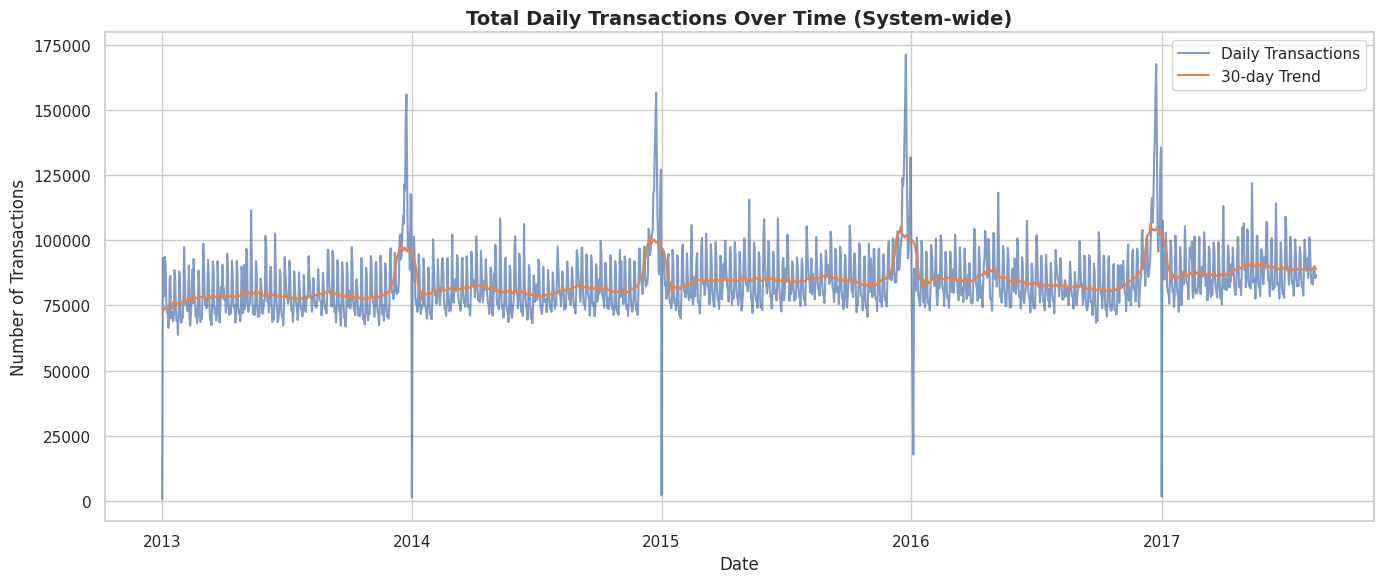

In [40]:
# Tính tổng số giao dịch của toàn hệ thống theo từng ngày
daily_tx = transactions.groupby('date')['transactions'].sum().reset_index()

plt.figure(figsize=(14, 6))
# 1. Vẽ dữ liệu thô (màu xám nhạt để không bị rối mắt)
sns.lineplot(data=daily_tx, x='date', y='transactions', alpha=0.7, label='Daily Transactions')

# 2. Vẽ đường xu hướng mượt 30 ngày (màu xanh dương) để thấy rõ chu kỳ
daily_tx['trend'] = daily_tx['transactions'].rolling(window=30, center=True, min_periods=1).mean()
sns.lineplot(data=daily_tx, x='date', y='trend', label='30-day Trend')

plt.title("Total Daily Transactions Over Time (System-wide)", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.legend()
plt.tight_layout()
plt.show()

Biểu đồ cho thấy tổng số giao dịch hằng ngày của toàn hệ thống bán lẻ có xu hướng tăng dần trong giai đoạn 2013 - 2017, đồng thời xuất hiện các seasonal spikes rất rõ rệt theo từng năm.

Trong giai đoạn đầu năm 2013, số lượng giao dịch trung bình dao động quanh khoảng 70,000 - 80,000 transactions/ngày. Tuy nhiên đến giai đoạn 2016 - 2017, mức trung bình đã tăng lên khoảng 85,000 – 95,000 transactions/ngày, cho thấy quy mô hoạt động và lượng khách hàng của hệ thống bán lẻ đang tăng trưởng theo thời gian.

Ngoài xu hướng tăng dài hạn, biểu đồ cũng cho thấy: các spike giao dịch rất lớn xuất hiện lặp lại gần đầu mỗi năm với nhiều thời điểm vượt mức 150,000 - 170,000 transactions/ngày. Điều này phản ánh sự tồn tại của: strong seasonality, holiday effects hoặc các dịp tiêu dùng cao điểm diễn ra định kỳ hằng năm.

Đặc biệt, đường xu hướng trung bình trượt 30 ngày cho thấy transaction volume không tăng đột biến ngẫu nhiên mà có xu hướng tăng ổn định theo thời gian. Điều này cho thấy: nhu cầu thị trường đang mở rộng, hệ thống cửa hàng có thể đang phát triển thêm hoặc lượng khách hàng trung thành đang tăng lên theo từng năm.

Ngoài ra, biểu đồ cũng xuất hiện một số điểm giảm cực mạnh xuống gần bằng 0 vào đầu các năm. Đây nhiều khả năng là: dữ liệu thiếu, ngày hệ thống chưa ghi nhận đầy đủ giao dịch,
hoặc các anomalous records thay vì phản ánh hành vi thực tế của thị trường. Đây là một dấu hiệu quan trọng trong data quality checking và cần được xử lý cẩn thận trước khi modeling.

Từ góc nhìn forecasting, transactions là một feature cực kỳ quan trọng vì nó phản ánh trực tiếp: customer traffic, demand intensity và mức độ hoạt động của hệ thống bán lẻ. Khi kết hợp với sales forecasting, transaction data có thể giúp mô hình: học được customer behavior, nhận diện peak demand periods và cải thiện khả năng dự báo trong các mùa cao điểm.

Ngoài ra, việc transaction volume có trend tăng dài hạn, seasonality rõ rệt và recurring spikes theo năm cho thấy forecasting model cần:
- xử lý temporal patterns tốt
- sử dụng lag features
- rolling statistics
- seasonal decomposition
- time-series specific features

-> để mô hình hóa chính xác hành vi giao dịch theo thời gian.

Từ góc nhìn kinh doanh biểu đồ này cho thấy hệ thống bán lẻ đang có xu hướng tăng trưởng lượng khách hàng và mức độ hoạt động theo thời gian. Tuy nhiên, các giai đoạn peak traffic rất lớn cũng đồng nghĩa doanh nghiệp cần: chuẩn bị inventory tốt hơn, tối ưu workforce allocation, tăng năng lực logistics và đảm bảo hệ thống vận hành ổn định để tránh stock-out, quá tải vận hành hoặc suy giảm trải nghiệm khách hàng trong các mùa tiêu dùng cao điểm.

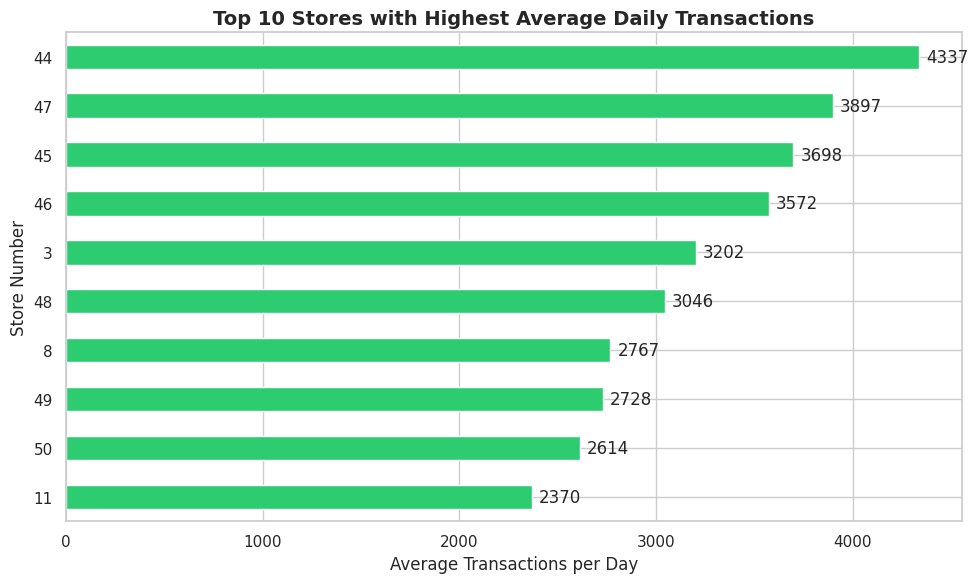

In [41]:
# Tính toán trung bình số giao dịch mỗi ngày của từng cửa hàng
store_tx = transactions.groupby('store_nbr')['transactions'].mean().sort_values(ascending=False).head(10)
# Đảo ngược để vẽ cột ngang từ lớn đến bé từ trên xuống
store_tx = store_tx.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
ax = store_tx.plot(kind='barh', color='emerald' if 'emerald' in locals() else '#2ecc71')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5)

plt.title("Top 10 Stores with Highest Average Daily Transactions", fontsize=14, fontweight='bold')
plt.xlabel("Average Transactions per Day")
plt.ylabel("Store Number")
plt.tight_layout()
plt.show()

Biểu đồ cho thấy lưu lượng giao dịch tập trung mạnh tại một số cửa hàng lớn như store 44 (~ 4,337 transactions/ngày) hay store 47 (~ 3,897), cao gần gấp đôi so với nhiều store khác trong top 10. Điều này cho thấy áp lực vận hành trong hệ thống bán lẻ đang phân bố không đồng đều.

Các cửa hàng có transaction volume cao không chỉ đóng vai trò tạo doanh thu chính mà còn là những điểm dễ phát sinh bottleneck về vận hành như quá tải quầy thanh toán, thiếu hàng, hoặc áp lực replenishment trong giờ cao điểm.

Từ góc nhìn kinh doanh, doanh nghiệp cần ưu tiên capacity planning cho nhóm high-traffic stores thông qua tăng nhân sự, tối ưu checkout, cải thiện logistics, và xây dựng inventory buffer phù hợp.

Ngoài ra, biểu đồ này cũng cho thấy rủi ro tập trung doanh thu vào một số ít cửa hàng lớn. Nếu xảy ra gián đoạn vận hành tại các store trọng điểm, tác động đến doanh thu toàn hệ thống có thể rất đáng kể.

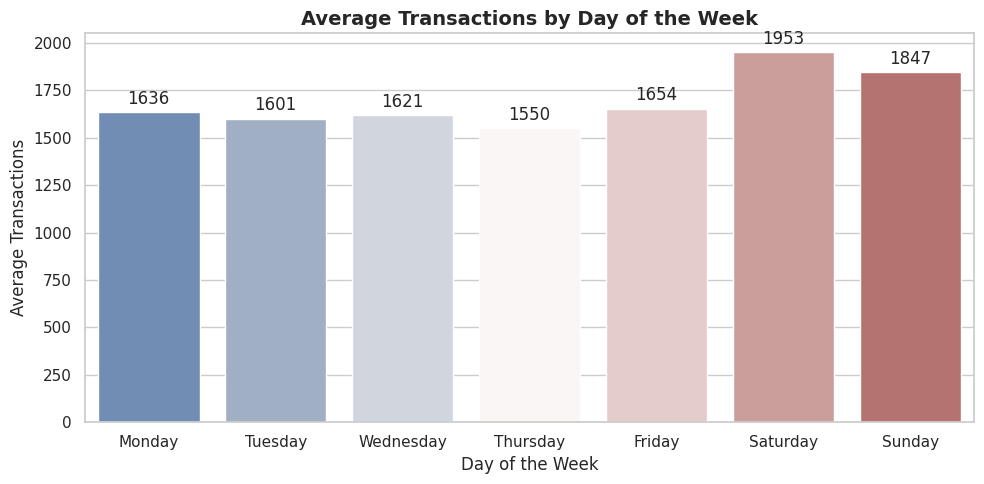

In [42]:
# Tạo thêm cột Thứ và Tháng để phân tích
transactions['date'] = pd.to_datetime(transactions['date'])
transactions['day_of_week'] = transactions['date'].dt.day_name()
transactions['month'] = transactions['date'].dt.month

# Thống kê theo thứ tự các thứ trong tuần
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_profile = transactions.groupby('day_of_week')['transactions'].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=weekly_profile.index, y=weekly_profile.values, palette="vlag", hue=weekly_profile.index, legend=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title("Average Transactions by Day of the Week", fontsize=14, fontweight='bold')
plt.xlabel("Day of the Week")
plt.ylabel("Average Transactions")
plt.tight_layout()
plt.show()

Biểu đồ cho thấy hành vi mua sắm của khách hàng thay đổi rõ rệt theo từng ngày trong tuần. Trong khi transaction volume các ngày Monday - Friday dao động khá ổn định quanh mức 1,550 - 1,650 giao dịch/ngày, lượng giao dịch tăng mạnh vào cuối tuần, đặc biệt Saturday đạt gần 1,953 transactions/day - mức cao nhất toàn tuần. **Điều này cho thấy cuối tuần là thời điểm người tiêu dùng thực hiện các hoạt động mua sắm lớn hơn cho gia đình hoặc nhu cầu tích trữ hàng hóa cho tuần tiếp theo**. Khách hàng không chỉ mua nhiều hơn mà còn có xu hướng dành nhiều thời gian hơn cho supermarket shopping trong weekend.

Ngoài ra, Thursday là ngày có transaction thấp nhất (~ 1,550), phản ánh đây có thể là giai đoạn “low shopping momentum” trước khi nhu cầu bắt đầu tăng trở lại vào Friday và bùng nổ vào cuối tuần.

Từ góc nhìn kinh doanh biểu đồ này cho thấy doanh nghiệp nên xem cuối tuần là “high customer engagement period” thay vì chỉ là peak sales period. Đây là thời điểm phù hợp để triển khai bundle promotions, cross-selling, sampling campaigns hoặc loyalty programs nhằm tối đa hóa giá trị mỗi khách hàng trong lúc customer traffic đạt cao nhất.

Ngược lại, các ngày giữa tuần có thể phù hợp hơn cho targeted discounts, customer retention campaigns hoặc operational optimization nhằm kích thích nhu cầu trong các low-traffic periods.